## 요약
- 기존 전처리 코드에서는 정수 인코딩한 token들도 scaling을 진행함
- transformer에서 embedding model을 사용하려면 정수 값으로 입력 받아야 함
- 또한 중고 도서 데이터가 아닌 도서 정보만 사용
- 이에 맞게 코드 수정

In [2]:
import os, natsort, re
from tqdm import tqdm
import time, random

In [3]:
from itertools import repeat, chain

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_percentage_error as mape
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import mean_squared_log_error as msle

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats("png2x")
# 테마 설정: "default", "classic", "dark_background", "fivethirtyeight", "seaborn"
mpl.style.use("fivethirtyeight")
# 이미지가 레이아웃 안으로 들어오도록 함
mpl.rcParams.update({"figure.constrained_layout.use": True})
mpl.rcParams['axes.unicode_minus'] = False

In [4]:
from google.colab import drive

drive.mount('/content/drive/', force_remount=True)

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
#cd /content/drive/MyDrive/AI3_prjct2_aladin/

In [ ]:
cd /content/drive/MyDrive/WASSUP-ESTsoft-AI/project/project2/

[Errno 2] No such file or directory: '/content/drive/MyDrive/WASSUP-ESTsoft-AI/project/project2/'
/home/doeun/code/AI/ESTSOFT2024/workspace/2.project_text/transformer_models/research


In [5]:
# 로컬에서

plt.rc("font", family = "D2Coding")
plt.rcParams["axes.unicode_minus"] = False

In [6]:
PRJCT_PATH = '/home/doeun/code/AI/ESTSOFT2024/workspace/2.project_text/transformer_models/'
#PRJCT_PATH = '/content/drive/MyDrive/WASSUP-ESTsoft-AI/project/project2/'
#PRJCT_PATH = '/content/drive/MyDrive/AI3_prjct2_aladin/aladin_usedbook/'
save_dir = 'processed/model_input'
dir_path = os.path.join(PRJCT_PATH,save_dir)
#dir_path = './'

In [7]:
dir_path

'/home/doeun/code/AI/ESTSOFT2024/workspace/2.project_text/transformer_models/processed/model_input'

In [8]:
import sys
sys.path.append(PRJCT_PATH)

In [9]:
RSLT_DIR = PRJCT_PATH + 'processed/'

bookinfo_name = 'bookinfo_ver{}.pkl'.format(1.0)
bookinfo_path = os.path.join(RSLT_DIR,bookinfo_name)

sys.path.append(PRJCT_PATH)
from module_aladin.file_io import load_pkl, save_pkl
from module_aladin.data_process import pd_datetime_2_datenum

from konlpy.tag import Mecab
from tensorflow.keras.preprocessing.sequence import pad_sequences
import itertools
from sklearn.preprocessing import MinMaxScaler

2025-03-25 19:39:39.639308: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-25 19:39:40.213182: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-25 19:39:40.364405: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2025-03-25 19:39:40.364462: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not ha

In [10]:
def set_corpus_size(freq,size_feat,mode):
    # 입력받은 mode와 size_feat에 따라 size 크기 결정
    if mode == 'uniform':
        cond = freq['counts']>=freq['counts'].iloc[size_feat]
        size = np.sum(cond)
    elif mode =='ths':
        cond = freq[freq['counts'] > size_feat]
        size = np.sum(cond)
    else :
        if size_feat == None : size = len(freq)
#        elif size_feat > len(data) : size = len(freq)
        else : size = size_feat
    return size

def make_encoding_by_freq(freq,null_val='[PAD]',size_feat=None,mode=None):
    #빈도수 기반 정수 인코딩 dict 만들기
    # freq : token 별 등장 빈도 (value_count), size_feat : size관련 변수(max_size, ths등), mode : size 결정 방법
    df_freq = pd.DataFrame(freq).T
    df_freq = df_freq.rename(columns={0:'token',1:'counts'})
    temp = df_freq.sort_values(by='counts',ascending=False)
    size = set_corpus_size(temp,size_feat,mode)
    temp = temp.iloc[:size]
    temp['val'] = np.arange(size)+1
    temp2 = temp.set_index('token').to_dict()
    map_token_encode = temp2['val']
    map_token_encode[null_val]=0
    return map_token_encode

def encode_tokens(map_token,x,oov=True):
    oov_val = len(map_token)+1 if oov else 0 
    return map_token[x] if x in map_token else oov_val

def make_author_encode_map(bookinfo,ths_author):
    pvtb = pd.pivot_table(data=bookinfo,index='Author',values='SalesPoint',aggfunc=np.sum)
    pvtb = pvtb.sort_values(by='SalesPoint',ascending=False)
    author_top_k= pvtb[pvtb['SalesPoint']>=ths_author].index
    encode_author = pd.DataFrame({'author' : author_top_k.values,'val':np.arange(1,len(author_top_k)+1)})
    encode_author = encode_author.set_index('author')
    return encode_author.to_dict()['val']

def make_publshr_encode_map(publshr_data,ths_publshr):
    stats = publshr_data.value_counts().sort_values(ascending=False)
    top_k_val = stats.iloc[ths_publshr]
    publshr_top_k = list(stats[stats >= top_k_val].index)
    return {
        publshr : n+1
        for n,publshr in enumerate(publshr_top_k)
    }
    

def make_store_encode_map(store_data):
    stores= store_data.value_counts().sort_values(ascending=False)
    return {
        place : n+1
        for n,place in enumerate(stores.index)
    }

In [11]:
file_name = 'bookinfo_ver{}.csv'.format(1.0)
file_path = os.path.join(RSLT_DIR,file_name)
bookinfo_raw = pd.read_csv(file_path)

In [12]:
cols = bookinfo_raw.columns.to_list()
x_idxs, y_idx = [0,2,3,4,5,6,9,10], 7
x_cols = [cols[i] for i in x_idxs]
y_col = cols[y_idx]

data_X, data_y  = bookinfo_raw[x_cols], bookinfo_raw[y_col]

In [13]:
from sklearn.model_selection import train_test_split

X_data, X_tst, y_data, y_tst = train_test_split(data_X,data_y,test_size=0.2,random_state=329)
X_trn, X_vld, y_trn, y_vld = train_test_split(X_data,y_data,test_size=0.2,random_state=329)

display(X_trn.columns)
display(X_trn.shape, y_trn.shape)
display(X_vld.shape, y_vld.shape)
display(X_tst.shape, y_tst.shape)

Index(['BName', 'BName_sub', 'Author', 'Publshr', 'Author_mul', 'Pdate',
       'SalesPoint', 'Category'],
      dtype='object')

(101173, 8)

(101173,)

(25294, 8)

(25294,)

(31617, 8)

(31617,)

In [14]:
data_dict = {
    'trn': {
        'X': X_trn,
        'y': y_trn
        },
    'vld':{
        'X': X_vld,
        'y': y_vld
        },
    'tst':{
        'X': X_tst,
        'y': y_tst
        
    }
}

from copy import deepcopy

data_raw = deepcopy(data_dict)

In [15]:
display(data_dict['trn']['X'].info())
display(data_dict['vld']['X'].info())
display(data_dict['tst']['X'].info())

<class 'pandas.core.frame.DataFrame'>
Index: 101173 entries, 96986 to 69788
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   BName       101172 non-null  object
 1   BName_sub   5760 non-null    object
 2   Author      101173 non-null  object
 3   Publshr     101173 non-null  object
 4   Author_mul  101173 non-null  bool  
 5   Pdate       101173 non-null  int64 
 6   SalesPoint  101173 non-null  int64 
 7   Category    101173 non-null  object
dtypes: bool(1), int64(2), object(5)
memory usage: 6.3+ MB


None

<class 'pandas.core.frame.DataFrame'>
Index: 25294 entries, 132734 to 43660
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   BName       25294 non-null  object
 1   BName_sub   1434 non-null   object
 2   Author      25294 non-null  object
 3   Publshr     25294 non-null  object
 4   Author_mul  25294 non-null  bool  
 5   Pdate       25294 non-null  int64 
 6   SalesPoint  25294 non-null  int64 
 7   Category    25294 non-null  object
dtypes: bool(1), int64(2), object(5)
memory usage: 1.6+ MB


None

<class 'pandas.core.frame.DataFrame'>
Index: 31617 entries, 146028 to 115151
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   BName       31617 non-null  object
 1   BName_sub   1813 non-null   object
 2   Author      31617 non-null  object
 3   Publshr     31617 non-null  object
 4   Author_mul  31617 non-null  bool  
 5   Pdate       31617 non-null  int64 
 6   SalesPoint  31617 non-null  int64 
 7   Category    31617 non-null  object
dtypes: bool(1), int64(2), object(5)
memory usage: 2.0+ MB


None

In [16]:
mecab = Mecab()
tokenizer_basic = lambda x : mecab.morphs(x)
#cut_date = lambda x : [x[:2],x[2:4],x[4:6],x[6:]]
#apply tokenizer
cols_vec = ['Category','BName','BName_sub']
cols_freq = ['Author','Publshr']

In [17]:
for mode, data in data_dict.items():
    bookinfo = data['X']
    for col in cols_vec:
        bookinfo[col] = bookinfo[col].fillna('').apply(tokenizer_basic)
    #bookinfo['Pdate'] = bookinfo['Pdate'].astype(str).apply(cut_date)
    bookinfo[['Author_mul','Pdate']] = bookinfo[['Author_mul','Pdate']].astype(int).astype(str)
    data_dict[mode]['X'] = bookinfo

In [18]:
#아래 ths 는 EDA 결과 제가 자의적으로 정한 내용
bookinfo = data_dict['trn']['X']
ths_author = int(np.round(len(bookinfo)/500)*75)
ths_publshr = int(np.round(len(bookinfo)/500)*5)

map_author_encode = make_author_encode_map(bookinfo[['Author','SalesPoint']],ths_author)
map_publshr_encode = make_publshr_encode_map(bookinfo['Publshr'],ths_publshr)

encode_maps = {
    'Author' : lambda x : encode_tokens(map_author_encode,x,oov=False),
    'Publshr' : lambda x : encode_tokens(map_publshr_encode,x,oov=False),
}

In [19]:
bookinfo_raw = data_raw['trn']['X']

In [20]:
y = data_dict['trn']['y']
bookinfo[y<1000]

,BName,BName_sub,Author,Publshr,Author_mul,Pdate,SalesPoint,Category
33477,[유혹],[],톰 아이젠맨,IVP,1,20011105,443,"[종교, /, 역학]"
50565,"[기독교, 교리, 교재]",[],루이스 벌코프,소망사,0,19930101,0,"[종교, /, 역학]"
49115,"[성령, 충만, 함, 을, 받, 는, 방법]",[],한국대학생선교회,순출판사,0,19860830,41,"[종교, /, 역학]"
33542,"[과학, 과, 기독교]",[],R. 호이카스,IVP,0,19850701,139,"[종교, /, 역학]"
23754,"[오직, 한, 길]",[],브리안 메이든,IVP,0,19860701,523,"[종교, /, 역학]"
34897,[헌신],[],하의진,IVP,0,19990201,154,"[종교, /, 역학]"
48070,"[만날, 때, 와, 헤어질, 때]",[],송인규,IVP,0,19900801,148,"[종교, /, 역학]"
34900,"[진정, 한, 종]",[],아지드 페르난도,IVP,1,20000918,165,"[종교, /, 역학]"
37813,"[자존, 감]",[],조안 로이드 게스트,IVP,0,19900501,404,"[종교, /, 역학]"
45782,"[의존, 관계, 의, 위험, 과, 극복]",[],로리 렌츨,IVP,1,19990325,113,"[종교, /, 역학]"


In [21]:
bookinfo[y>=100000]
temp = bookinfo.loc[y>=100000,'BName'].apply(lambda x : '세트' in x)
np.mean(temp)

0.6686746987951807

In [22]:
bookinfo[y>=100000][~temp]

,BName,BName_sub,Author,Publshr,Author_mul,Pdate,SalesPoint,Category
20619,"[김지하, 사상, 전집, -, 전, 3, 권]",[],김지하,실천문학사,0,20021018,73,[인문학]
52947,"[식품, 재료, 사전]",[],식품재료사전편찬위원회,한국사전연구사,0,20010820,25,"[대학, 교재, /, 전문, 서적]"
76319,"[유네스코, 세계, 문화유산]",[],마르코 카타네오.자스미나 트리포니,생각의나무,1,20100725,929,[역사]
135260,"[에브리, 데이, 스터디, 바이블]","[(, 개역, 개정, )]",틴데일하우스 출판사,성서유니온선교회,1,20211201,1686,"[종교, /, 역학]"
42329,"[비트겐슈타인, 선집, -, 전, 7, 권]",[],루트비히 비트겐슈타인,책세상,1,20061023,352,[인문학]
47015,"[삐, 아제, New, 리틀, 베이비, 픽, 쳐, 북, -, 전, 20, 권]",[],한국삐아제,한국삐아제,0,20071001,214,"[전집, /, 중고, 전집]"
86499,"[1900, 년, 이후, 의, 미술사]",[],할 포스터,세미콜론,1,20120820,1189,"[예술, /, 대중, 문화]"
15923,"[빌딩, 관리사, 수험서, -, 전, 5, 권]",[],조병갑,범론사,1,20010110,33,"[수험서, /, 자격증]"
78362,"[하늘, 은, 붉, 은, 강가, 애, 장판, -, 전, 16, 권]",[],시노하라 치에,학산문화사(만화),0,20100129,241,[만화]
6928,"[COLOR, ATLAS, 임상, 의학]",[],전국의과대학임상교수,한우리,0,19981115,20,"[대학, 교재, /, 전문, 서적]"


In [25]:
cond = (y>60000) & (y<100000)
bookinfo[cond]

,BName,BName_sub,Author,Publshr,Author_mul,Pdate,SalesPoint,Category
90365,"[2014, 경, 록, 공인, 중개사, 1, 차, 기본, 서, 세트, -, 전, 2...",[],경록부동산교육연구소,경록,0,20140115,431,"[수험서, /, 자격증]"
59182,"[꼭, 읽, 어야, 할, 소설, 119, 세트, -, 전, 10, 권]",[],김혜니,타임기획,1,20040421,1470,[청소년]
154749,"[주인공, 의, 구원자, 가, 될, 운명, 입니다, 1, ~, 5, 세트, -, 전...",[],은소로,연담,0,20240401,1321,"[소설, /, 시, /, 희곡]"
69754,"[트와일라잇, 특별, 판, 세트, -, 전, 4, 권]",[],스테프니 메이어,북폴리오,1,20111125,631,"[소설, /, 시, /, 희곡]"
51710,"[추의, 역사]",[],움베르토 에코,열린책들,1,20081230,1805,[인문학]
...,...,...,...,...,...,...,...,...
156466,"[성경, 신학]",[],존 오웬,언약(도서출판),1,20240418,1505,"[종교, /, 역학]"
102440,"[드래곤, 라자, 세트, -, 전, 8, 권]",[],이영도,황금가지,0,20081127,4062,"[소설, /, 시, /, 희곡]"
91347,"[맑스, 사전]",[],마토바 아키히로,비(도서출판b),1,20111028,359,[인문학]
109781,"[커피, 한, 잔, 할까요, ?, 1, ~, 8, 세트, -, 전, 8, 권]",[],허영만.이호준,위즈덤하우스,0,20170331,1061,[만화]


0.016368003321044152
0.020222786711869768


<Axes: xlabel='RglPrice', ylabel='Count'>

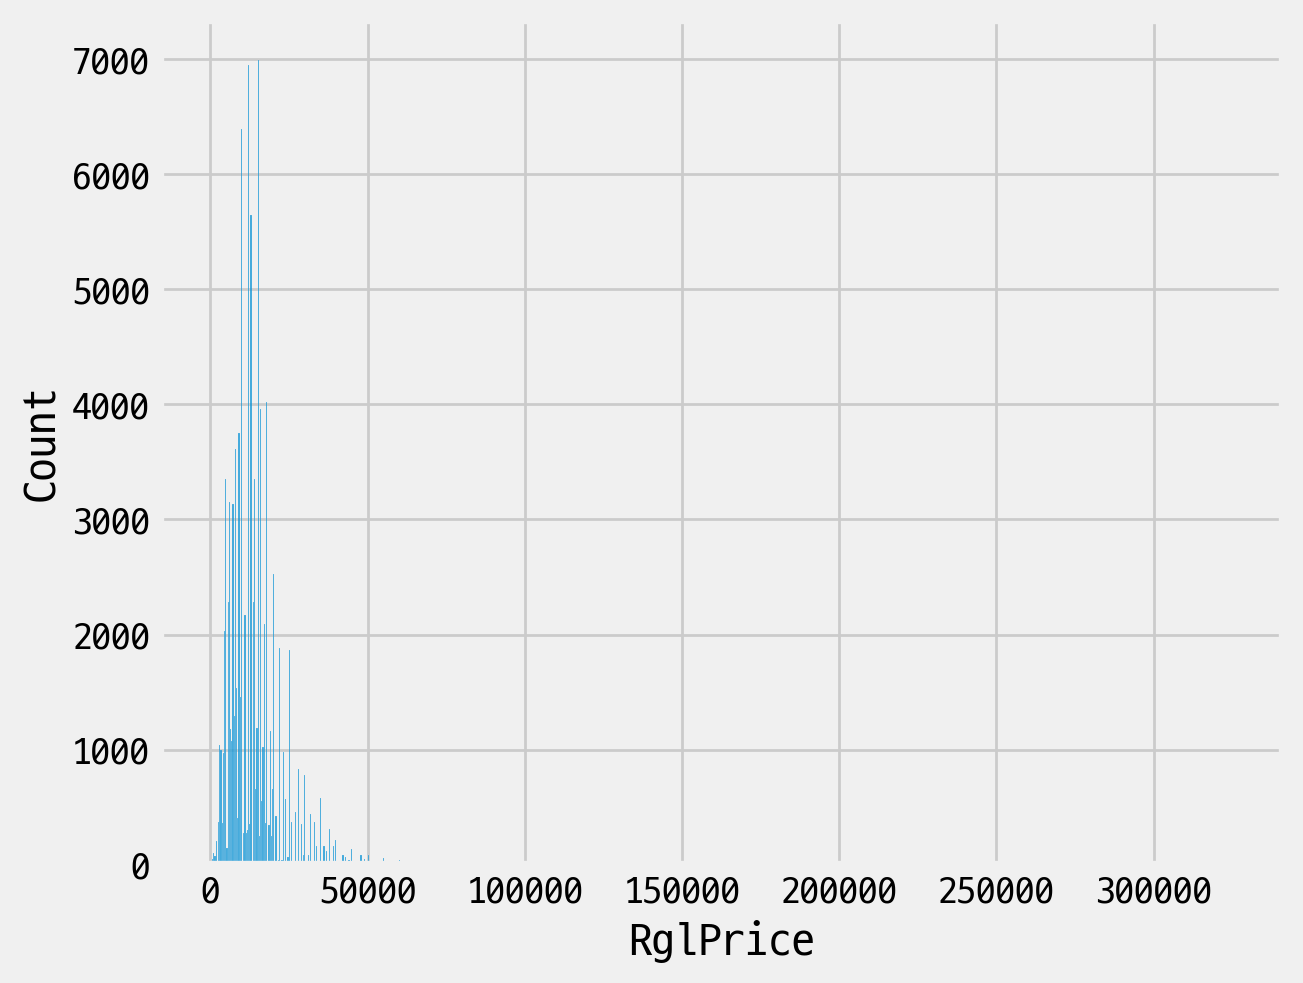

In [26]:
cond1 = bookinfo['BName'].apply(lambda x: '세트' in x)
cond20 = bookinfo['BName'].apply(lambda x: '전' in x)
cond21 = bookinfo['BName'].apply(lambda x: '권' in x)
cond2 = cond20 & cond21
print(np.mean(cond1))
print(np.mean(cond2))

#sns.histplot(y[cond1 | cond2])
sns.histplot(y[(~cond) & (~cond2)])

In [27]:
display(bookinfo[((y>100000)&(~cond1))&(~cond2)])
display(y[((y>100000)&(~cond1))&(~cond2)])

,BName,BName_sub,Author,Publshr,Author_mul,Pdate,SalesPoint,Category
76319,"[유네스코, 세계, 문화유산]",[],마르코 카타네오.자스미나 트리포니,생각의나무,1,20100725,929,[역사]
152034,"[스와핑, 리, 미티, 드, 에디션]",[],채팔이,해피북스투유,0,20230630,320,"[소설, /, 시, /, 희곡]"
51153,"[하늘, 에서, 본, 한국]",[],얀 아르튀스-베르트랑,새물결,1,20081115,409,"[예술, /, 대중, 문화]"
89951,"[ESV, 스터디, 바이블]","[(, 가죽, 장정, )]",크로스웨이 ESV 스터디 바이블 편찬팀,부흥과개혁사,0,20140501,3507,"[종교, /, 역학]"
157037,"[2024, 레저, 백서]",[],서천범,한국레저산업연구소,0,20240517,2115,"[건강, /, 취미]"
55173,[진상],[],이동천,동아일보사,0,20080520,173,"[예술, /, 대중, 문화]"
52811,"[원예, 수목, 병해충, 방제, 도감]",[],학술편수관 편집부,학술편수관,0,20040220,44,[과학]
44304,"[원색, 한국, 식물도감]",[],이영노,교학사,0,20020915,247,[과학]
135741,"[레인보우, 시티, 리, 미티, 드, 에디션]",[],채팔이,해피북스투유,0,20220228,1001,"[소설, /, 시, /, 희곡]"
4820,"[중국, 정사, 조선, 열, 국전]",[],김성구,동문선,0,19960301,36,[역사]


76319     120000
152034    150000
51153     120000
89951     130000
157037    250000
55173     138000
52811     160000
44304     190000
135741    110000
4820      120000
6353      120000
105360    110000
57445     120000
122244    150000
41614     120000
153015    108000
41949     120000
76320     120000
24538     135000
9831      120000
118628    120000
Name: RglPrice, dtype: int64

In [28]:
display(bookinfo[(y>100000)&(~cond1)&(~cond2)])
display(y[(y>100000)&(~cond1)&(~cond2)])

,BName,BName_sub,Author,Publshr,Author_mul,Pdate,SalesPoint,Category
76319,"[유네스코, 세계, 문화유산]",[],마르코 카타네오.자스미나 트리포니,생각의나무,1,20100725,929,[역사]
152034,"[스와핑, 리, 미티, 드, 에디션]",[],채팔이,해피북스투유,0,20230630,320,"[소설, /, 시, /, 희곡]"
51153,"[하늘, 에서, 본, 한국]",[],얀 아르튀스-베르트랑,새물결,1,20081115,409,"[예술, /, 대중, 문화]"
89951,"[ESV, 스터디, 바이블]","[(, 가죽, 장정, )]",크로스웨이 ESV 스터디 바이블 편찬팀,부흥과개혁사,0,20140501,3507,"[종교, /, 역학]"
157037,"[2024, 레저, 백서]",[],서천범,한국레저산업연구소,0,20240517,2115,"[건강, /, 취미]"
55173,[진상],[],이동천,동아일보사,0,20080520,173,"[예술, /, 대중, 문화]"
52811,"[원예, 수목, 병해충, 방제, 도감]",[],학술편수관 편집부,학술편수관,0,20040220,44,[과학]
44304,"[원색, 한국, 식물도감]",[],이영노,교학사,0,20020915,247,[과학]
135741,"[레인보우, 시티, 리, 미티, 드, 에디션]",[],채팔이,해피북스투유,0,20220228,1001,"[소설, /, 시, /, 희곡]"
4820,"[중국, 정사, 조선, 열, 국전]",[],김성구,동문선,0,19960301,36,[역사]


76319     120000
152034    150000
51153     120000
89951     130000
157037    250000
55173     138000
52811     160000
44304     190000
135741    110000
4820      120000
6353      120000
105360    110000
57445     120000
122244    150000
41614     120000
153015    108000
41949     120000
76320     120000
24538     135000
9831      120000
118628    120000
Name: RglPrice, dtype: int64

In [29]:
idx = y[(~cond1)&(~cond2)].argmax()
bookinfo[(~cond1)&(~cond2)].iloc[idx]

BName         [2024, 레저, 백서]
BName_sub                 []
Author                   서천범
Publshr            한국레저산업연구소
Author_mul                 0
Pdate               20240517
SalesPoint              2115
Category         [건강, /, 취미]
Name: 157037, dtype: object

In [30]:
cond3 = bookinfo['BName'].apply(lambda x : '백서' in x)
y[cond3]

54181       5000
115046     15000
68302      15800
46253      10000
71785      33000
41960      19000
36576      12000
108617     40000
109462     16800
37858       9800
49647      11000
41281      13800
56823      13800
41654       9800
157037    250000
85476       4800
75113      20000
88460       4800
74060      25000
41672      11000
156312     26000
68275      16000
8666       18000
84252      15500
41328       9800
20075       9800
41541       9500
65414      12000
72050      18000
11474      12000
81931      30000
62477      15800
154888     19000
135372     24000
52367      23000
56332      10000
52908      24000
Name: RglPrice, dtype: int64

In [31]:
bookinfo.iloc[y.argmax()]

BName                    [노벨라, 33, 세트, -, 전, 33, 권]
BName_sub     [(, 활판, 인, 쇄, 양장, 1, 천, 세트, 한, 정판, )]
Author                             미겔 데 세르반테스 사아베드라
Publshr                                         다빈치
Author_mul                                        1
Pdate                                      20231122
SalesPoint                                     1499
Category                          [소설, /, 시, /, 희곡]
Name: 149087, dtype: object

In [32]:
cond3 = bookinfo.BName.apply(lambda x: '-' in x)
cond4 = bookinfo.BName.apply(lambda x: '권' in x)
#cond5 = bookinfo.BName.apply(lambda x: '전' in x)
np.mean(y[cond3&cond4] < 35000)#&cond5]

0.43050847457627117

<Axes: xlabel='BName', ylabel='Count'>

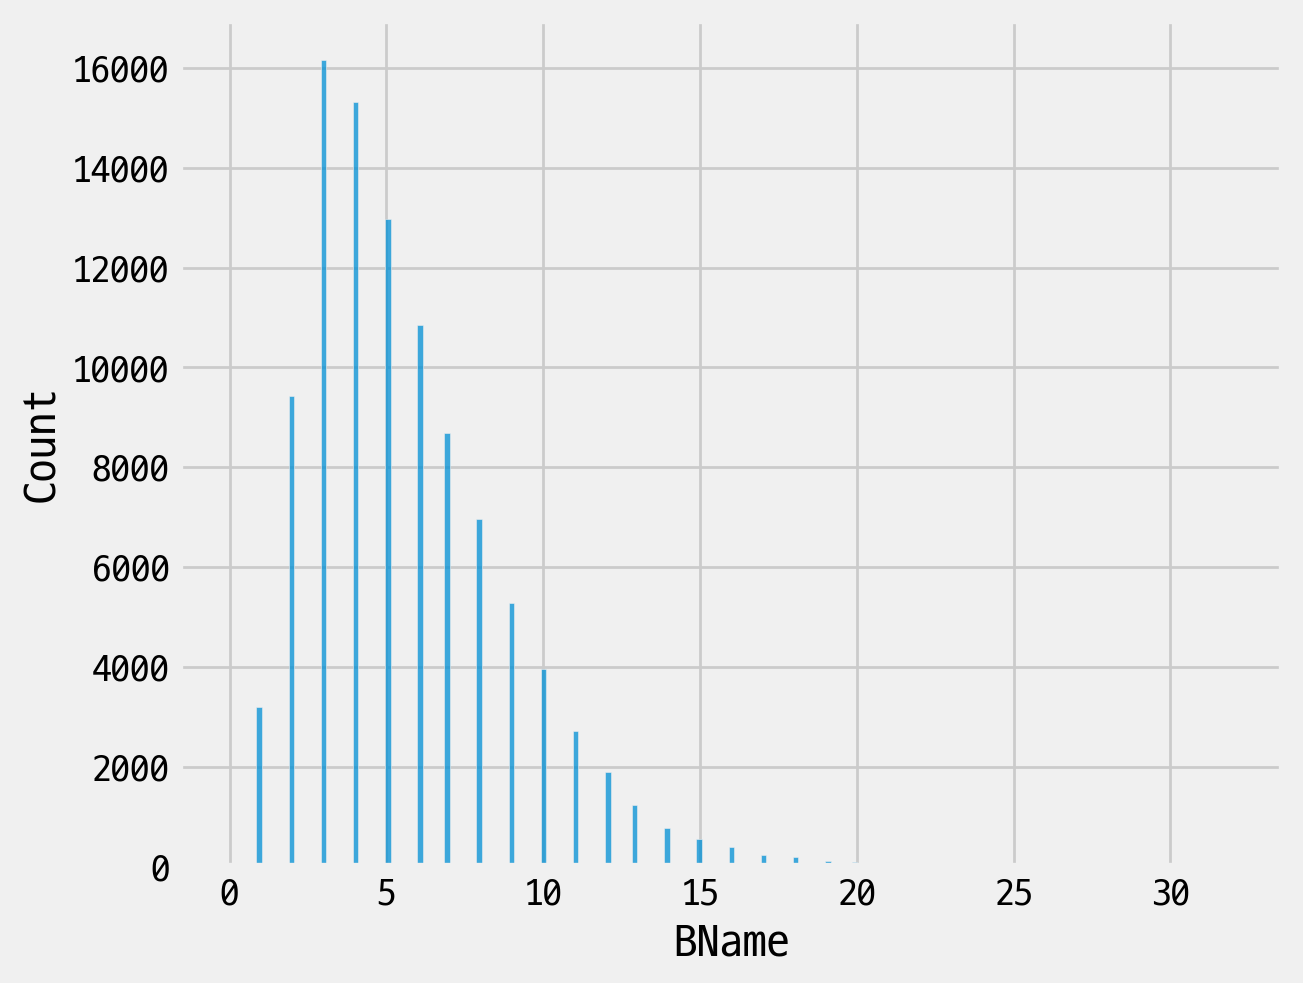

In [33]:
sns.histplot(bookinfo.BName.apply(lambda x: len(x)))

<Axes: xlabel='RglPrice', ylabel='Count'>

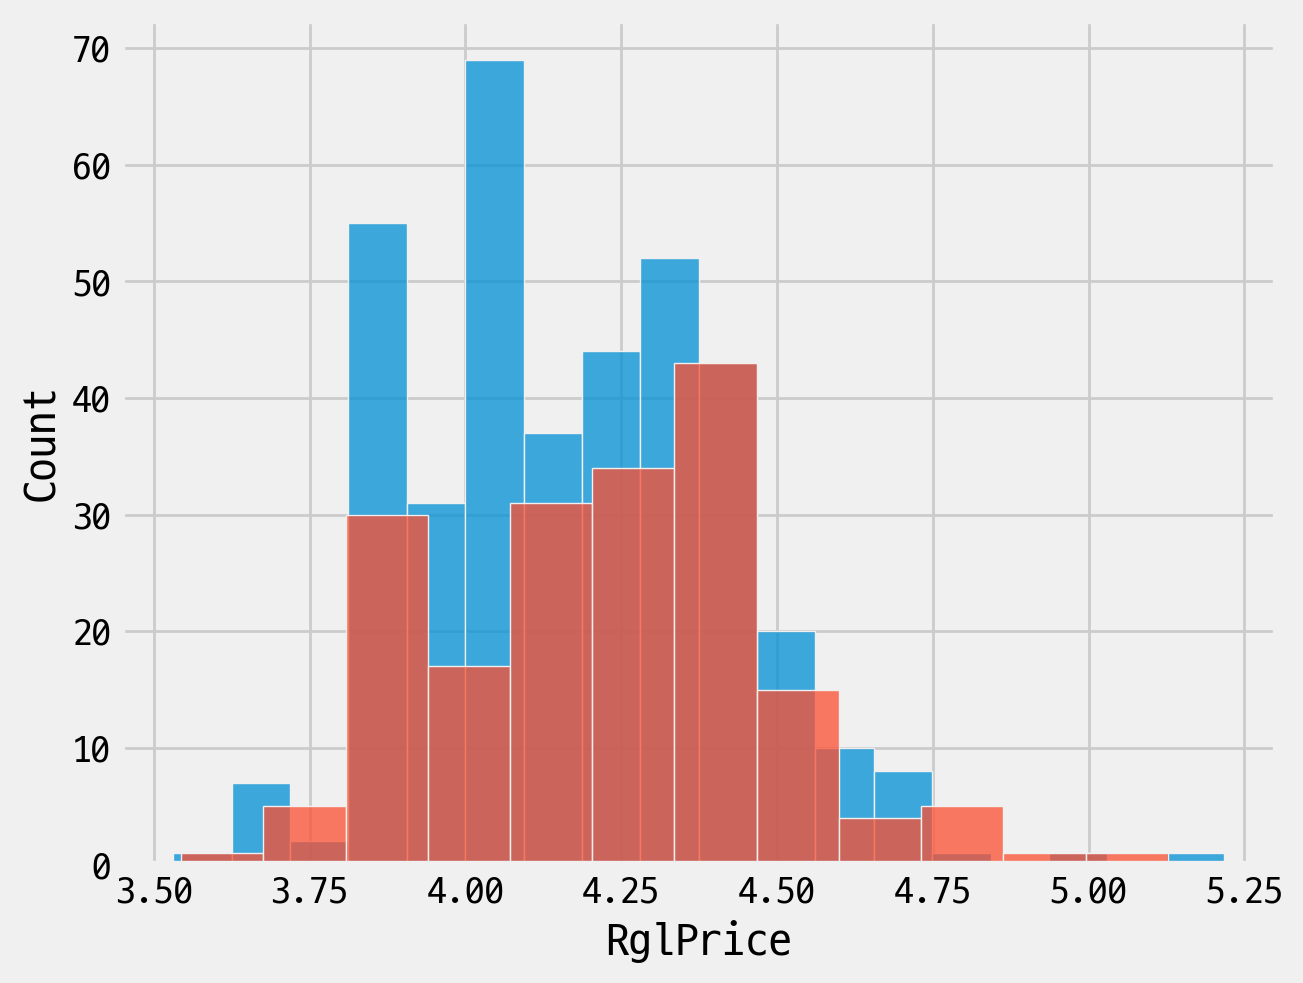

In [34]:
cond = bookinfo.BName.apply(lambda x :len(x)>17)
cond2 = bookinfo.BName.apply(lambda x :len(x)>20)
bookinfo[cond].BName
sns.histplot(np.log10(y[cond & (~cond2)]))
sns.histplot(np.log10(y[cond2]))

In [33]:
cond = bookinfo.BName.apply(lambda x :len(x)>17)
bookinfo[cond]

,BName,BName_sub,Author,Publshr,Author_mul,Pdate,SalesPoint,Category
156227,"[2024, 전라북도, 교육청, 교육, 공무, 직원, 소양, 평가, 기출문제, +,...",[],취업채널,북스케치,0,20240301,1739,"[수험서, /, 자격증]"
125488,"[젊은이, 들, 의, 흑마, 법, 기피, 가, 심각, 합니다, 만, ,, 취직, 해...",[],모리타 키세츠,㈜소미미디어,1,20190816,242,"[소설, /, 시, /, 희곡]"
125990,"[어쩌다, 보, 니, SNS, 마케팅, 으로, 월, 1000, 을, 버, 는, 사람...",[],정현주,황금부엉이,0,20190904,484,"[경제, 경영]"
20334,"[10, 대, 에, 꿈, 을, 꾸, 고, 20, 대, 에, 준비, 하, 여, 30,...",[],원 베네딕트,상상북스,0,20021004,1814,"[종교, /, 역학]"
128915,"[역시, 내, 청춘, 러브, 코메디, 는, 잘못, 됐, 다, :, 망언, 록, 9,...",[],카즈키 레치,디앤씨미디어(주)(D&C미디어),1,20200110,60,[만화]
...,...,...,...,...,...,...,...,...
157227,"[생각, 한, 대로, 말, 할, 수, 없, 어, 답답, 했, 던, 개발자, 를, 위...",[],카이마이 미즈히로,프리렉,1,20240517,3980,"[컴퓨터, /, 모바일]"
121887,"[절대로, 일, 하, 고, 싶, 지, 않, 은, 던전, 마스터, 가, 늘어지, 게,...",[],오니카게 스패너,서울문화사,1,20190116,237,"[소설, /, 시, /, 희곡]"
106967,"[변변찮, 은, 마술, 강사, 와, 금기, 교전, 소설, 8, 권, +, 만화, 3...",[],히츠지 타로,디앤씨미디어(주)(D&C미디어),1,20171110,316,"[소설, /, 시, /, 희곡]"
89512,"[2014, 9, 급, 운전, 직, 공무원, 한, 권, 으로, 끝내, 기, :, 사...",[],SD 공무원 수험연구회,시대고시기획,0,20140515,159,"[수험서, /, 자격증]"


In [35]:
bookinfo_raw[cond]

,BName,BName_sub,Author,Publshr,Author_mul,Pdate,SalesPoint,Category
156227,2024 전라북도교육청 교육공무직원 소양평가 기출문제+직무능력검사+인성검사+면접,NaN,취업채널,북스케치,False,20240301,1739,수험서/자격증
125488,"젊은이들의 흑마법 기피가 심각합니다만, 취직해보니 대우도 좋고 사장도 사역마도 귀여...",NaN,모리타 키세츠,㈜소미미디어,True,20190816,242,소설/시/희곡
125990,어쩌다 보니 SNS마케팅으로 월 1000을 버는 사람이 되어버렸다!,NaN,정현주,황금부엉이,False,20190904,484,경제경영
20334,10대에 꿈을 꾸고 20대에 준비하여 30대에 영향력을 발하는 인생이 되라,NaN,원 베네딕트,상상북스,False,20021004,1814,종교/역학
128915,역시 내 청춘 러브코메디는 잘못됐다 : 망언록 9~10 합본 세트 - 전2권,NaN,카즈키 레치,디앤씨미디어(주)(D&C미디어),True,20200110,60,만화
...,...,...,...,...,...,...,...,...
157227,"생각한 대로 말할 수 없어 답답했던 개발자를 위한 생각의 정리, 문서 작성법",NaN,카이마이 미즈히로,프리렉,True,20240517,3980,컴퓨터/모바일
121887,절대로 일하고 싶지 않은 던전 마스터가 늘어지게 잠을 자기까지 6,NaN,오니카게 스패너,서울문화사,True,20190116,237,소설/시/희곡
106967,변변찮은 마술강사와 금기교전 소설 8권 + 만화 3권 합본 세트 - 전2권,NaN,히츠지 타로,디앤씨미디어(주)(D&C미디어),True,20171110,316,소설/시/희곡
89512,"2014 9급 운전직 공무원 한권으로 끝내기 : 사회, 자동차구조원리 및 도로교통법규",NaN,SD 공무원 수험연구회,시대고시기획,False,20140515,159,수험서/자격증


<Axes: xlabel='BName_sub', ylabel='Count'>

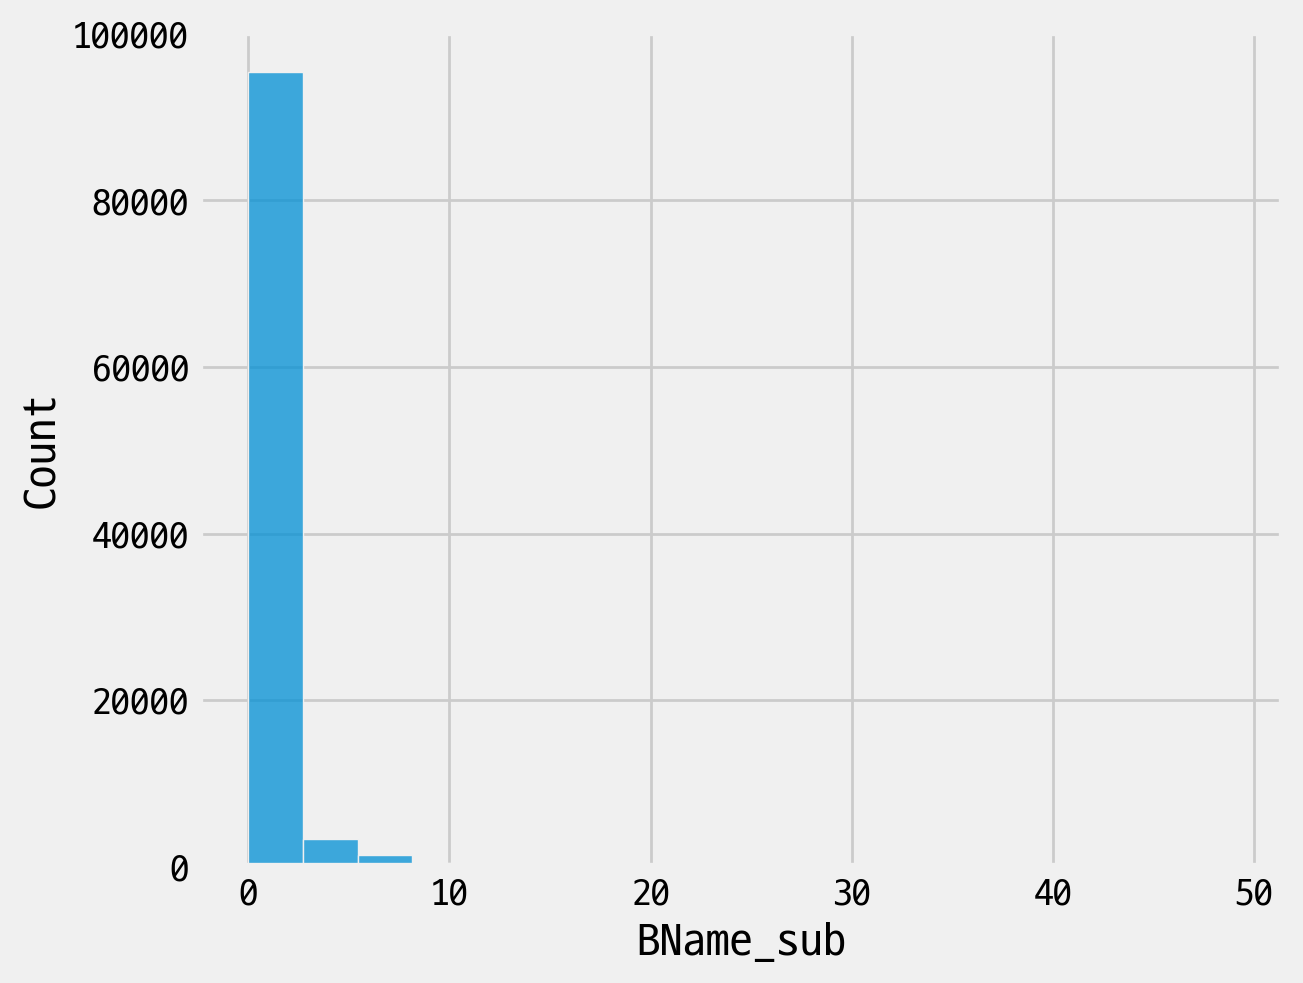

In [34]:
sns.histplot(bookinfo.BName_sub.apply(lambda x: len(x)))

<Axes: xlabel='RglPrice', ylabel='Count'>

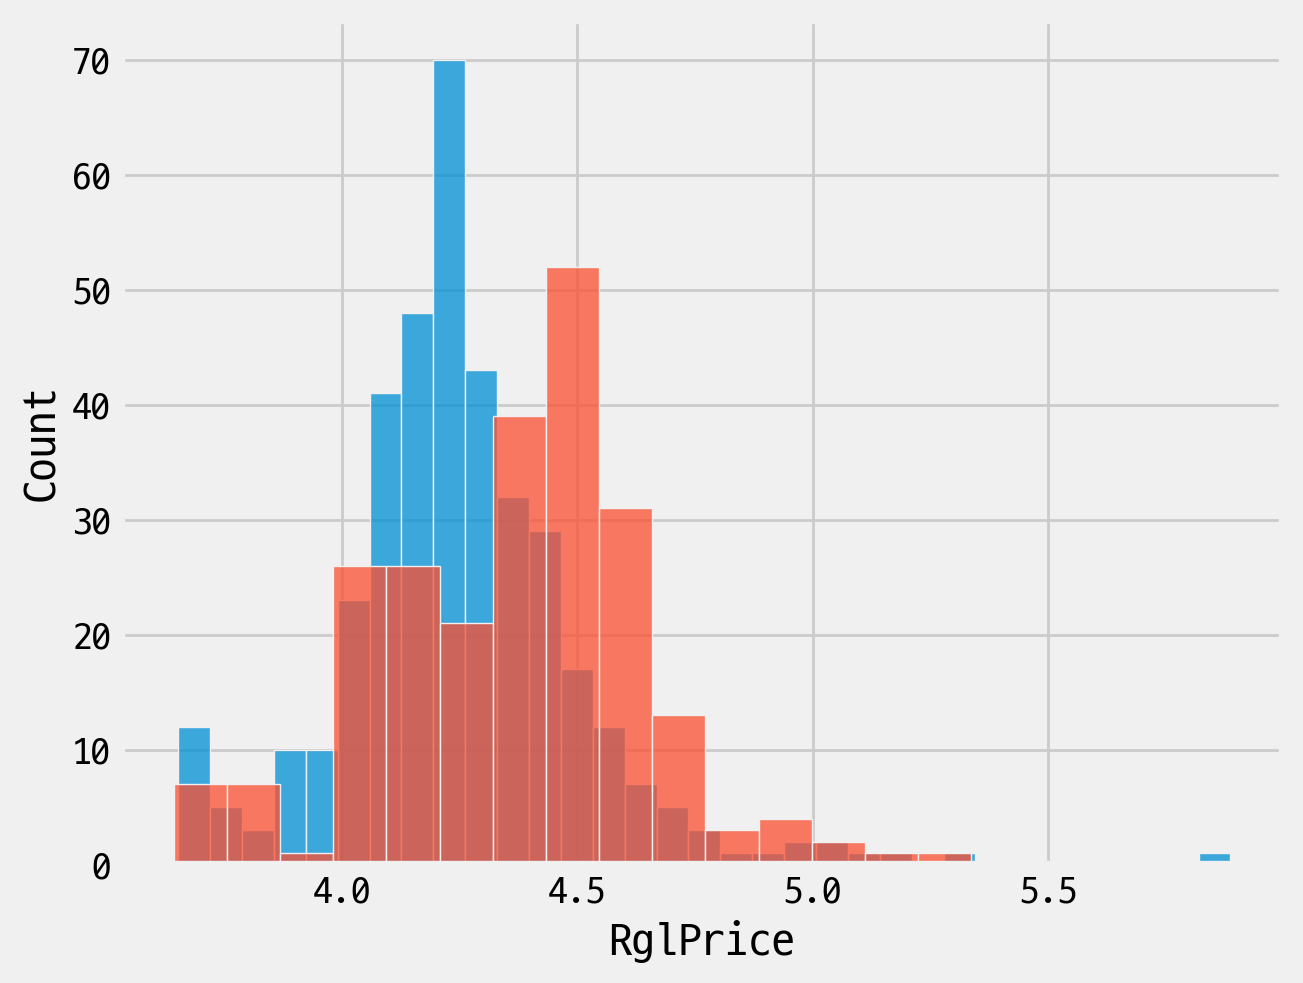

In [35]:
cond = bookinfo.BName_sub.apply(lambda x : len(x)>10)
cond2 = bookinfo.BName_sub.apply(lambda x : len(x)>15)

sns.histplot(np.log10(y[cond & (~cond2)]))
sns.histplot(np.log10(y[cond2]))

<Axes: xlabel='RglPrice', ylabel='Count'>

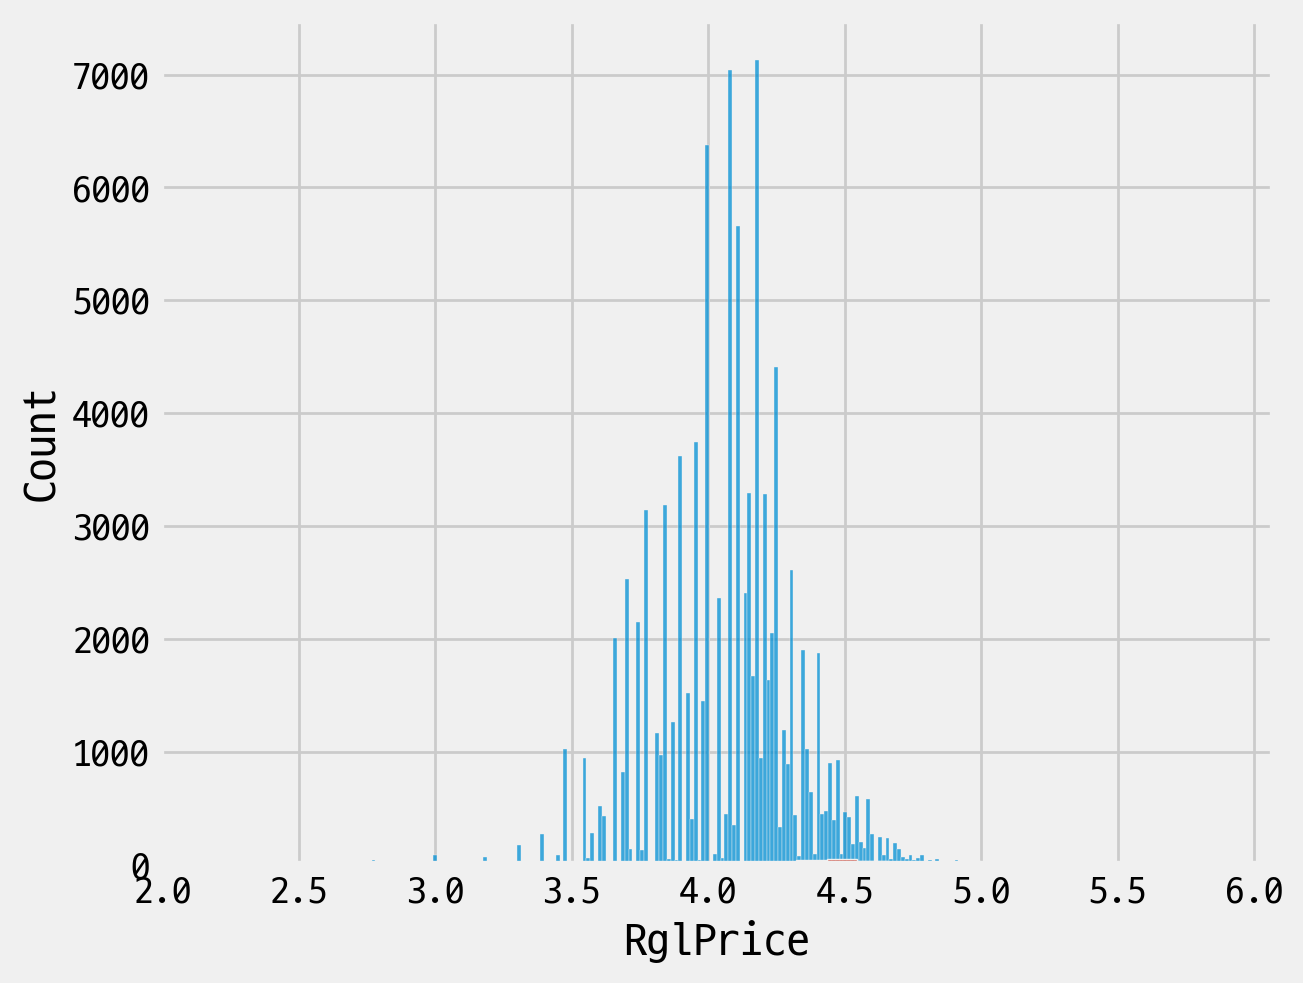

In [36]:
sns.histplot(np.log10(y[~cond2]))
sns.histplot(np.log10(y[cond2]))

<Axes: xlabel='RglPrice', ylabel='Count'>

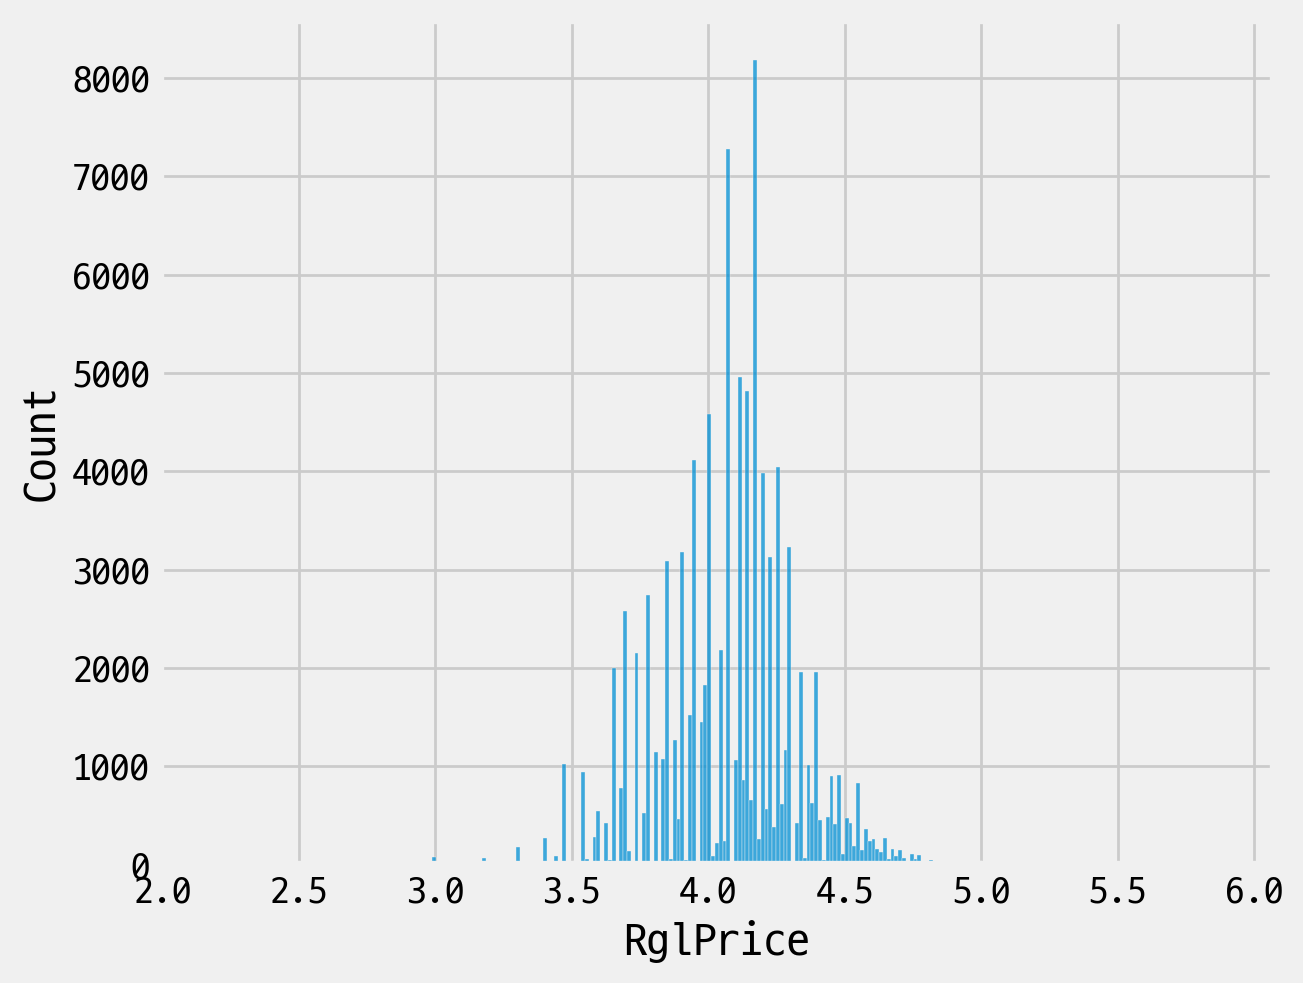

In [37]:
sns.histplot(np.log10(y))

In [50]:
cond0=bookinfo.BName.apply(lambda x : '세트' in x)
cond1=bookinfo.BName.apply(lambda x : '패키지' in x)
cond20=bookinfo.BName.apply(lambda x : '전' in x)
cond21=bookinfo.BName.apply(lambda x : '-' in x)
cond22=bookinfo.BName.apply(lambda x : '권' in x)
cond3=bookinfo.BName.apply(lambda x : '묶음' in x)

cond2 = (cond20 | cond21) & cond22

display(np.mean(cond0))
display(np.mean(cond1))
display(np.mean(cond2))
display(np.mean(cond3))
display(np.mean((cond1 | cond2) | cond0 | cond3))

0.016368003321044152

0.00024710149941189845

0.020568728811046426

5.9304359858855625e-05

0.023365917784389116

In [62]:
temp = bookinfo_raw.loc[cond2&(~cond0&~cond1&~cond3),['BName','BName_sub','Pdate']]
temp['price'] = y[cond2&(~cond0&~cond1&~cond3)]

In [63]:
temp.iloc[0:60]

,BName,BName_sub,Pdate,price
152191,2024 백광훈 통합 형사소송법 - 전2권,NaN,20230520,56000
122063,2019 전효진 헌법 기출문제집 - 전3권,NaN,20190130,42000
136411,2021 해커스 경찰 갓대환 형사소송법 기본서 - 전2권,NaN,20210205,38500
92482,2016 김종석 행정법총론 - 전2권,NaN,20150711,42000
20619,김지하 사상전집 - 전3권,NaN,20021018,105000
109889,오소마츠 6쌍둥이 공식 앤솔로지 - 전3권,(캔배지 6종 포함 한정판),20170414,27000
62542,조태준의 쉐리봉 우쿨렐레 - 전2권,NaN,20100705,13000
92322,2016 해동 한국사 기출정해 - 전3권,NaN,20151020,32000
99343,2017 공무원 강민성 한국사 - 전3권,NaN,20160707,43000
133425,2022 이동기영어 유형별 기출문제집 - 전4권,NaN,20210830,43000


In [65]:
temp.iloc[60:120]

,BName,BName_sub,Pdate,price
36640,쇼퍼홀릭 3권 - 1,NaN,20050927,8000
36983,쇼퍼홀릭 2권 - 1,NaN,20050725,8000
29085,테르미도르 - 전3권,NaN,20030510,24000
107497,영어탈피 초급편 - 전4권,NaN,20171009,54000
99359,2017 써니 행정법총론 - 전3권,NaN,20160808,43000
37763,대한민국사 - 전3권,NaN,20050815,33000
42329,비트겐슈타인 선집 - 전7권,NaN,20061023,109000
115420,은하영웅전설 박스 2 - 전4권,(5~8권),20180221,48000
76302,2013 7.9급 재정 국어 기출문제집 - 전2권,NaN,20121213,38000
119943,2020 써니 행정법총론 기출문제집 - 전2권,NaN,20191020,40000


In [66]:
temp.iloc[120:180]

,BName,BName_sub,Pdate,price
74516,달과 6펜스 - 전2권,(한글판 + 영문판),20120928,15800
112819,2019 신영식 해동한국사 - 전3권,NaN,20180716,50000
107314,2018 고혜원 혜원국어 기출정해 - 전2권,NaN,20171130,39000
101327,액셀 월드 20 + 액셀 월드 코믹스 7 - 전2권,(합본호),20161213,11500
80779,2014 민주국사 - 전3권,NaN,20130923,49000
93983,2016 시나공 컴퓨터활용능력 2급 필기 + 기출문제집 - 전2권,NaN,20151113,19000
141657,2023 이동기영어 실전 독해 500제 - 전2권,NaN,20221025,33000
112220,2019 이동기 공무원 유형별 영어 기출문제집 - 전3권,NaN,20180824,41000
140688,2023 유휘운 행정법총론 진도별 기출문제집 - 전2권,(진출),20221007,46000
134335,2022 전한길 한국사 3.0 기출문제집 - 전2권,NaN,20211031,41000


In [67]:
temp.iloc[180:240]

,BName,BName_sub,Pdate,price
154390,2024 소방단기 김동준 소방관계법규 디딤돌 모의고사 - 전2권,(공개채용),20240105,24000
146204,2023 에듀윌 9급 공무원 기본서 영어 - 전3권,NaN,20220623,45000
112707,2019 신영식 해동한국사 기출정해 - 전3권,NaN,20180920,37000
112349,2019 신용한 Compass 행정학개론 9급 기본서 - 전2권,NaN,20180629,42000
70257,문학동네 걸작 미니북 컬렉션 - 전6권,NaN,20111220,21000
75222,2013 써니 행정법총론 - 전3권,NaN,20121010,45000
99211,이동기 영어 - 전3권,NaN,20160630,45000
18699,한권으로 끝내는 2종투자상담사 Point-Up 학습서,NaN,20010702,25000
140038,2022 김건호 행정법총론 최근 10년 단원별 기출문제집 - 전2권,NaN,20210831,42000
116620,문재인 대통령 헌법개정안 - 전2권,NaN,20180420,6600


In [68]:
temp.iloc[240:300]

,BName,BName_sub,Pdate,price
119081,2020 써니 행정법총론 : 기출지문 암기 App 이용쿠폰 제공 - 전3권,NaN,20190725,46000
150457,2023 김중규 ALL바른 기출문제 선행정학 - 전3권,NaN,20220711,42000
81557,2014 해커스 패스닷컴 공무원 영어 - 전3권,"(문법, 독해, 어휘)",20130916,46900
92237,2016 ACL 김중근 형법 - 전3권,(총론 + 각론 12),20150910,55000
123424,올인원 실전 220제 + 강의노트 - 전2권,NaN,20190109,32000
112107,2018 ACL 김중근 형사소송법 OX 문제집 - 전2권,NaN,20170918,34000
133566,2022 김중규 5.0 기출문제 선행정학 - 전3권,NaN,20210630,42000
146333,2023 고종훈 한국사 6개년 단원별 기출문제 1200제 - 전2권,NaN,20220718,33000
59062,배재민 2009 통합 Subnote - 전2권,NaN,20090102,44000
58249,기동전사 건담 소설 - 전3권,NaN,20091210,24000


In [69]:
temp.iloc[300:360]

,BName,BName_sub,Pdate,price
156607,2025 이유진 국어 독해 알고리즘 코어 - 전2권,NaN,20240507,25000
59688,New 알기 쉽게 해설한 Java With a Workbook - 전2권,NaN,20071201,20000
82871,리어 왕 - 전2권,(한글판 + 영문판),20130215,6600
151632,2023 김건호 헌법 비교불가 헌법 기출지문 OX - 전3권,NaN,20230331,50000
144795,로스쿨 민사 사례형의 정석 기출문제 완전분석 - 전2권,NaN,20220425,48000
13273,조선의 정쟁 - 전5권,NaN,20010530,32000
112898,2018 정보보안기사 산업기사 실기 - 전2권,NaN,20180316,37000
24431,김소진 전집 - 전6권,NaN,20020723,54000
157895,2025 선재국어 수비니겨 기본서 - 전2권,NaN,20240715,32000
90664,나의 드로잉 다이어리 : 나무를 그리다 - 전2권,NaN,20140527,13800


In [71]:
temp.iloc[360:420]

,BName,BName_sub,Pdate,price
75194,데미안 - 전2권,(한글판 + 영문판),20130101,6600
101689,2017 아인슈타인 암기법에 의한 조동훈 소방학개론 - 전2권,NaN,20160908,36000
100376,2017 해동 한국사 기출정해 - 전3권,NaN,20161030,35000
86684,2015 황남기 객관식 헌법 기출문제 총정리 - 전2권,NaN,20140808,44000
128903,2020 ACL 김중근 형법 기본서 - 전2권,NaN,20191216,63000
99581,2016 합격 위생사 필기시험문제 - 전2권,"(저자직강 동영상 90강, 공중위생관리법 부록집을 제공하는)",20160920,30000
100124,2017 MANI 행정학 기출 빅데이터 - 전2권,NaN,20160920,40000
120281,2020 갓대환 형법 기출 1200제 - 전2권,NaN,20191104,46000
102623,2016 시나공 정보처리기사 실기 + 기출문제집 - 전2권,(산업기사 포함),20160129,29000
88600,2014 선재국어 기출실록 - 전3권,NaN,20140103,38000


In [72]:
temp.iloc[420:480]

,BName,BName_sub,Pdate,price
118342,Trinity of Macroeconomics 트리니티 거시경제학 - 전2권,(ver.5.0),20180727,43000
137132,2021 전효진 헌법 기출문제집 - 전4권,NaN,20210302,43000
106488,2018 정현 기출 1000제 - 전2권,NaN,20170929,35000
78664,노르웨이의 숲 - 전2권,NaN,20080414,24000
92281,2016 EBS 신용한 Compass 행정학 - 전2권,NaN,20150720,42000
99527,2017 신용한 Compass 행정학개론 기본서 - 전2권,NaN,20160711,42000
81536,2014 EBS 선우한국사 이론편 - 전2권,NaN,20130805,46000
56972,9급 Passtory 민주국사 - 전3권,NaN,20090630,40000
113549,데이트 어 라이브 19 + 데이트 어 불릿 4 - 전2권,(합본판),20181110,14000
93839,2016 배미진 알찬국어 유형별 공무원 기출 - 전2권,NaN,20151124,36000


In [73]:
temp.iloc[480:540]

,BName,BName_sub,Pdate,price
28989,한권으로 끝내는 공인중개사 - 1차대비,NaN,20030102,25000
92151,2016 전한길 한국사 2.0 All in One - 전2권,NaN,20150710,45000
87959,2015 배미진 알찬국어 유형별 기출문제집 - 전2권,NaN,20141110,35000
114218,2019 혜원국어 기출정해 - 전2권,NaN,20181210,44000
78708,카프카 소설선 - 전5권,NaN,20051227,89000
105997,2018 김종석 행정법총론 기출문제집 - 전2권,NaN,20170730,39000
30077,파리로 가다 - 전2권,NaN,20030620,17000
128773,2021 해커스 공무원 국어 - 전4권,NaN,20200706,49800
68977,방과 후에 약속한 소녀 상.하권 합본판 - 전2권,NaN,20111101,14000
47831,칼의 노래 100만부 기념 소장본 - 전2권,NaN,20071224,35000


In [74]:
temp.iloc[540:600]

,BName,BName_sub,Pdate,price
92973,2016 ACL 김중근 형법 OX 문제집 - 전2권,(문제편 + 해설편),20151005,35000
119708,2020 민준호 사회 기출문제집 - 전2권,NaN,20191021,38000
74952,더클래식 셜록 홈즈 전집 - 전9권,(반양장),20120518,35000
153580,2024 민준호 독학 행정법 기본서 - 전2권,NaN,20230731,33000
55263,교육법전 2008 - 전2권,NaN,20080420,78000
20819,근원 김용준 전집 - 전6권,NaN,20070521,116000
2152,중국 고전 이야기 - 첫째권,NaN,20000129,12000
127396,2021 전효진 행정법총론 - 전3권,NaN,20200615,47000
140937,2023 30일 완성 손진숙 영문법 900제 - 전3권,NaN,20220907,32000
135668,7일만에 끝내는 간호사 국가고시 2065제 최종모의고사 - 전2권,NaN,20211012,29000


In [76]:
temp.iloc[600:660]

,BName,BName_sub,Pdate,price
82492,2013 공단기 영어 - 전3권,NaN,20120705,48000
94882,2015 EBS 선우한국사 이론편 - 전3권,NaN,20140720,47000
92242,2016 써니 행정법총론 - 전3권,NaN,20150810,43000
92277,2016 ACL 김중근 형사소송법 기본서 - 전2권,NaN,20150910,47000
107209,2018 태종 국어 화룡점정 기출문제집 - 전2권,NaN,20171103,28000
135941,2021 해커스 공무원 한국사 - 전3권,NaN,20200706,44900
50992,Passtory 9급 민주국사 - 전3권,NaN,20080723,38000
61511,배재민 2009 1차 객관식 입문과 연습 - 전2권,NaN,20090710,46000
58935,바람계곡의 나우시카 박스판 - 전7권,NaN,20100201,42000
86709,변태왕자와 웃지 않는 고양이 8 + 아트북 - 전2권,(한정판),20141013,29800


In [77]:
temp.iloc[660:]

,BName,BName_sub,Pdate,price
101582,2017 한 권으로 완성하는 고득점 독해 300제 - 전2권,NaN,20161226,26000
58571,모리와 함께한 화요일 + 천국에서 만난 다섯 사람 - 전2권,NaN,20091116,11700
127520,2021 갓대환 형사소송법 기출 1000제 - 전2권,NaN,20201028,44000
134657,2022 김수환 소방영어 테마 모의고사 - 전2권,[STEP 3],20201105,28000
92491,2016 시나공 컴퓨터활용능력 1급 실기 - 전3권 + 엑셀 함수 사전 + 자동 채...,"(엑셀, 액세스 2007 사용자용)",20151002,35000
131807,문재인 대통령 연설문집 제3권 - 전3권,NaN,20200605,25000
123427,2020 선재국어 법원직 - 전2권,NaN,20190412,36000
149969,2023 소방단기 김동준 소방관계법규 디딤돌 모의고사 - 전2권,(공개채용),20230111,22000
112132,2019 전한길 한국사 합격생 필기노트 + 빵꾸노트 - 전2권,NaN,20180716,21000
26421,9급 Text 국어만세 - 전2권,NaN,20050912,33000


In [53]:
temp = bookinfo_raw.loc[cond0&(~cond2),['BName','BName_sub']]
temp['price'] = y[cond0&(~cond2)]

display(temp.iloc[0:50])
display(np.mean(temp['price']>=20000))

,BName,BName_sub,price
122410,미쓰백 박스 세트,NaN,29000
117334,소드 월드 2.0 한정판 세트,NaN,45000
70589,피아노 어드벤쳐 3급 세트,(교재 4권 + CD 1장),27500
73551,워킹데드 Walking Dead 1~5 세트,NaN,42500
131347,BTS 직소퍼즐 세븐 4종 세트,(미니 클리어파일 4종 + PET 인쇄 투명 포토카드 4종 + 홀로그램 특수 인쇄 ...,55000
44369,다시쓰는 택리지 세트,(전 5권),82000
33457,오장육부를 되살리는 배 마사지 30분 세트,(책 + 옥 배밀이 + 고급 비단천),29500
43614,로마인 이야기 13권 세트,(증정 : 로마인 이야기 14권),147000
13390,아이와 함께 만드는 꼬마영어그림책 - 세트 1,(전3권),19000
133270,바른연애 길잡이 외전 + 북케이스 포함 세트,NaN,13000


0.6481481481481481

In [42]:
display(temp.iloc[50:100])
display(np.mean(temp['price'].iloc[50:100]>=20000))

,BName,BName_sub,price
41840,예수와 함께한 저녁식사 + 예수와 함께한 가장 완벽한 하루 세트,NaN,16800
44719,EBS 공인중개사 1차 세트 2006,NaN,58000
37273,디오판토스가 들려주는 방정식 이야기 + 독서활용노트 세트,NaN,10500
100830,치즈 인 더 트랩 시즌 3 세트,(3),33000
126823,ETS 토익 정기시험 예상문제집 RC 실전 5세트 All New 최신개발,(리딩),12500
151361,이번 생은 가주가 되겠습니다 1부 3 세트,(엽서 5종+아크릴 북마크 3종+브로마이드 포함 한정판),32000
33534,베스트 태교동화 세트,NaN,36000
94788,포목점 은여우의 연애기담 2 직소퍼즐 한정판 박스세트,NaN,18000
144032,룩 백 + 체인소 맨 11권 합본 세트,NaN,12000
68400,그 청년 바보의사 + 북라이트 기프트 세트,NaN,20000


0.5

In [43]:
display(temp.iloc[100:150])
display(np.mean(temp['price'].iloc[100:150]>=20000))

,BName,BName_sub,price
48494,<청소부밥> + <배려> 선물세트,NaN,20000
21204,연탄길 1.2.3 - 세트,NaN,22500
112451,타샤 튜더 컬렉션 특별 세트,(도서 6권 + 다이어리),87000
99950,"안녕, 우리 들꽃 컬러링북 + 아르누보 50색 색연필 세트",NaN,37000
121195,가장 친절한 타로 + 웨이트 카드 세트,NaN,33000
54253,룬의 아이들 - 윈터러 애장판 세트,NaN,59200
82209,치즈 인 더 트랩 시즌 2 : 한정판 세트,(2),35000
156676,스파이더맨: 웨딩 앨범 + 스파이더버스 BOOK 1-2 + 슬립 북케이스 + 스파이...,NaN,134000
147324,카구야 님은 고백받고 싶어 28 합본세트,(한정판),18000
111558,어댑티브 리더십 토크카드 세트,(전5권 + 토크카드),38000


0.78

In [44]:
display(temp.iloc[150:200])
display(np.mean(temp['price'].iloc[150:200]>=20000))

,BName,BName_sub,price
6226,신재용의 TV로 보는 동의보감 선물세트,NaN,19500
43269,뱀파이어 기사 한정판 박스 세트,NaN,9500
130852,사신 도련님과 검은 메이드 1~2 합본세트,NaN,12000
135090,나이트런 네가 있는 마을 10권 특별판 세트,(완결) + 제로(0),47000
153993,새벽의 노래 3 한정판 세트,NaN,18500
36545,생로병사의 비밀 1~2 세트,NaN,25000
151667,새벽의 노래 2 한정판 세트,NaN,11000
28767,일본어 초보 세트 2,(교재 1권 + 주해서 1권 + 테이프 3개),22000
27159,레베르테 소장본 세트,NaN,33500
31883,17세의 나레이션 1~2 세트,(완결),14000


0.56

In [46]:
display(temp.iloc[200:235])
display(np.mean(temp['price'].iloc[200:235]>=20000))

,BName,BName_sub,price
79797,소드 아트 온라인 1~9 세트,(묶음),63000
46765,만화 토지 제1부 1~7권 세트,NaN,70000
138587,아이돌 마스터 밀리언라이브 한국 한정 특전 세트,(일러스트 카드 4종 + B3 포스터 + 일러스트 무릎 담요 포함),62000
26647,캔디 캔디 애장판 1~5 세트,(완결),42500
79110,타임슬립 닥터 진 1~19 세트,(묶음),85500
107213,오늘의 네코무라 씨 아홉 + 2018 오늘의 네코무라 씨 탁상 캘린더 세트,(한정판),20000
68136,저칼로리 도시락 60세트,NaN,13500
153916,사랑하는 소년 특별판 세트,(완결),128000
93132,드래곤볼 풀컬러판 마인 부우 편 1~6 박스세트,NaN,71400
87764,비밀의 정원 엽서책 필통 세트,NaN,22000


0.7142857142857143

In [47]:
display(temp.iloc[235:])
display(np.mean(temp['price'].iloc[235:]>=20000))

,BName,BName_sub,price
103748,피어나다 두번째 + 매트 + 크롬커터 세트,NaN,30000
31915,은비가 내리는 나라 1~4 세트,NaN,28000
84311,문학소녀의 추상화랑 2 세트,(본책 + 반숙작가와 ‘문학소녀’ 편집자 + 데스크 패드),34000
109478,너의 이름은. 클리어파일 세트,NaN,3000
31900,팔운성 1~19권 세트,NaN,57500
102330,카피책 키트 세트,NaN,18000
44113,세계사와 함께 읽는 중국사 대장정 3권 세트,NaN,26400
27321,e짠돌이가 2000원으로 밥상차리기 세트,NaN,18600
80232,야스 화보집 토라도라 픽처스! 세트,(야스 화보집 + 토라도라 스핀오프! 3 + 캐릭터 지퍼 파일),29800
78006,명상 고전 + 내 인생의 가장 행복한 30분 세트,NaN,25000


0.6857142857142857

In [48]:
temp = bookinfo_raw.loc[cond1&(~cond2),['BName','BName_sub']]
temp['price'] = y[cond1&(~cond2)]

display(len(temp))
display(temp.iloc[0:50])
display(np.mean(temp['price']>=20000))

14

,BName,BName_sub,price
84548,2014 취업성공패키지 상담원 Final 합격문제,NaN,23000
90332,트리플 패키지,NaN,16000
98420,2015 취업성공패키지상담원 final 합격문제,NaN,23000
51774,가정교사 히트맨 리본! 20 한정 패키지,(가정교사 히트맨 리본! 20권 + 가정교사 히트맨 리본! Vongola77 + 일...,15000
29122,틱낫한 스님 방한 기념 특별 패키지 세트,NaN,20000
71401,패키지 디자인,NaN,20000
84481,2014 취업성공패키지 상담원 한권으로 통과하기,(사회/고용보험법령/직업상담학 포함),30000
82140,왕의 재정학교 워크북 패키지,NaN,30000
123333,2019 민준호 사회 지방직.교행직 대비 풀패키지,NaN,16000
83204,"2014 취업성공패키지 상담원 한권으로 통과하기 : 사회,고용보험법령",(인터넷 모의고사 무료 제공),26000


0.7142857142857143

In [49]:
temp = bookinfo_raw.loc[cond1&(cond2),['BName','BName_sub']]
temp['price'] = y[cond1&(cond2)]

display(len(temp))
display(temp.iloc[0:50])
display(np.mean(temp['price']>=20000))

11

,BName,BName_sub,price
80006,시나공 토익 만점의 법칙 패키지 - 전7권,(20회분 문제집 + 파트별 해설집 +오답노트),52000
76253,하야테처럼! 0권 + 하야테처럼! 32권 패키지 - 전2권,NaN,11000
83805,2013 EBS 교육방송교재 물류관리사 패키지 - 전5권,(기출문제해설집 증정 + 2012년기출문제해설 강의무료제공 + 동영상강의 할인쿠폰 포함),110000
142032,펀치 드렁크 러브 시즌 1 : 1~2 스페셜 패키지 - 전2권,NaN,56000
154731,스케치 시즌 1 : 주빈 FOCUS 풀패키지 1~2 - 전2권,NaN,65000
48896,신의 물방울 와이드판 VIP 패키지 세트 - 전10권,NaN,75000
51339,기욤 뮈소 베스트 패키지 - 3권 묶음,NaN,29400
155685,스케치 시즌 2 : A 풀패키지 SYMPATHY - 전2권,NaN,65000
156405,스케치 시즌 2 : B 풀패키지 SYMPATHY - 전2권,(완결),69000
149502,위험한 편의점 시즌2 스페셜 패키지 - 전2권,NaN,54000


0.8181818181818182

In [37]:
display(bookinfo_raw[cond0&(~cond2)].iloc[100:150,0:2])
display(np.mean(y[cond0&(~cond2)].iloc[100:150]>20000))
#display(bookinfo[cond1&(~cond2)])

,BName,BName_sub
48494,<청소부밥> + <배려> 선물세트,NaN
21204,연탄길 1.2.3 - 세트,NaN
112451,타샤 튜더 컬렉션 특별 세트,(도서 6권 + 다이어리)
99950,"안녕, 우리 들꽃 컬러링북 + 아르누보 50색 색연필 세트",NaN
121195,가장 친절한 타로 + 웨이트 카드 세트,NaN
54253,룬의 아이들 - 윈터러 애장판 세트,NaN
82209,치즈 인 더 트랩 시즌 2 : 한정판 세트,(2)
156676,스파이더맨: 웨딩 앨범 + 스파이더버스 BOOK 1-2 + 슬립 북케이스 + 스파이...,NaN
147324,카구야 님은 고백받고 싶어 28 합본세트,(한정판)
111558,어댑티브 리더십 토크카드 세트,(전5권 + 토크카드)


0.7

In [80]:
bookinfo[cond20&~cond22]

,BName,BName_sub,Author,Publshr,Author_mul,Pdate,SalesPoint,Category
77655,"[죽, 기, 전, 에, 답해야, 할, 101, 가지, 질문]",[],잭 캔필드 & 마크 빅터 한센,토네이도,1,20120319,633,"[자기, 계발]"
129646,"[2020, 전, 한길, 한, 국사, 7, ., 0, 주제, 별, 최종, 점검]",[],전한길,에스티유니타스,0,20200220,509,"[수험서, /, 자격증]"
29032,"[못가, 못가, 내, 눈, 에, 흙, 이, 들어가, 기, 전, 에]",[],김진성,징검다리,0,20010519,23,"[소설, /, 시, /, 희곡]"
112448,"[목, 양면, 방화, 사건, 전, 말기]",[],이기호,현대문학,0,20180825,896,"[소설, /, 시, /, 희곡]"
125480,"[장난, 을, 잘, 치, 는, 전, 타카기, 양, 5]",[],야마모토 소이치로,대원씨아이(만화),1,20190808,631,[만화]
...,...,...,...,...,...,...,...,...
49068,"[전, 산응, 용, 기계, 제도, 실기]","[(, CAD, )]",다솔기계설계교육연구소,느낌이좋은책(엑스파일),0,20050405,387,"[컴퓨터, /, 모바일]"
149033,"[용, 랑, 전, 9, :, 왕패, 입국, 편]",[],야마하라 요시토,학산문화사(만화),0,20231116,1401,[만화]
119857,"[방, 한림, 전]",[],이상구,문학동네,0,20170925,597,"[소설, /, 시, /, 희곡]"
145805,"[전, 대대, 실격, 1]",[],하루바 네기,학산문화사(만화),0,20220616,770,[만화]


(array([ 3000,  3500,  4000,  4500,  4800,  5000,  5500,  5900,  6000,
        6500,  6800,  7000,  7500,  7800,  7900,  8000,  8500,  8900,
        9000,  9500,  9800, 10000, 10800, 11000, 11200, 11500, 11800,
       12000, 12800, 13000, 13500, 13800, 13900, 14000, 14500, 14800,
       14900, 15000, 15300, 15800, 16000, 16800, 17000, 17500, 18000,
       18500, 18800, 19000, 19500, 19800, 20000, 21000, 21500, 21900,
       22000, 23000, 24000, 25000, 26000, 27000, 28000, 29000, 30000,
       32000, 33000, 34000, 35000, 37000, 38000, 39000, 40000, 42000,
       43000]), array([ 2,  2,  4,  7,  3, 20, 14,  1,  8,  2,  1,  7,  8,  7,  1, 15,  7,
        1, 12,  7,  7, 19,  2,  9,  3,  4,  1, 42,  5, 24,  6,  4,  1, 12,
        2,  4,  1, 32,  1,  7, 20,  5, 11,  1, 15,  1,  1,  5,  1,  1, 16,
        2,  1,  1, 14,  5,  1,  3,  2,  1,  5,  3,  5,  6,  4,  3,  4,  1,
        2,  4,  2,  1,  1]))


<Axes: xlabel='RglPrice', ylabel='Count'>

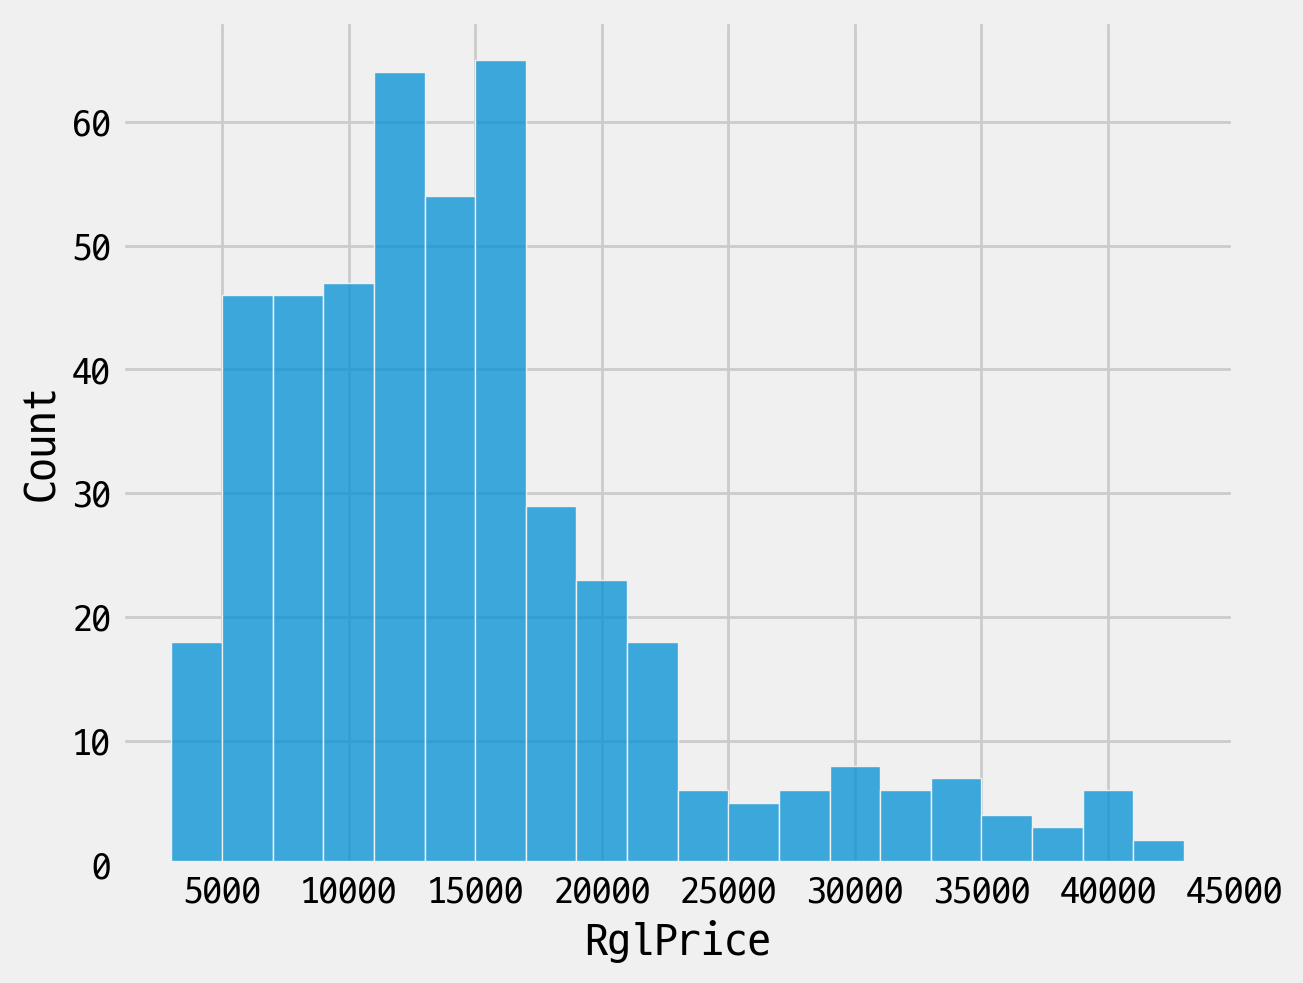

In [82]:
print(np.unique(y[cond20&~cond22],return_counts=True))
sns.histplot(y[cond20&~cond22])

In [84]:
cond = y[cond20&~cond22]>=20000
temp = bookinfo_raw[cond20&~cond22][cond]
temp['price'] = y[cond20&~cond22][cond]
temp.iloc[0:50]

,BName,BName_sub,Author,Publshr,Author_mul,Pdate,SalesPoint,Category,price
129646,2020 전한길 한국사 7.0 주제별 최종점검,NaN,전한길,에스티유니타스,False,20200220,509,수험서/자격증,21900
53578,죽기 전에 꼭 봐야 할 자연 절경 1001,NaN,마이클 브라이트,마로니에북스,True,20080120,560,여행,39000
86392,2015 전한길 한국사 3.0 기출문제집,NaN,전한길,에스티앤북스(ST&BOOKS),False,20140920,2375,수험서/자격증,28000
119914,"모든 것은 영원했다, 사라지기 전까지는",NaN,알렉세이 유르착,문학과지성사,True,20190930,1409,사회과학,32000
42757,죽기 전에 가봐야 할 1000곳,NaN,패트리샤 슐츠,이마고,False,20060529,917,여행,23000
137720,2021 전효진 행정법총론 전범위 모의고사 + 실전기출 Vol.2,NaN,전효진,연승,False,20210215,355,수험서/자격증,20000
124255,2019 NCS 한국남동발전 직업기초능력평가 & 실전모의고사,NaN,NCS직무능력연구소,시대고시기획,False,20190520,54,수험서/자격증,22000
148568,"대해전, 최강국의 탄생",NaN,폴 케네디,한국경제신문,True,20231030,1117,역사,40000
53035,전차종 센서 점검 정비 2,NaN,경영사 편집부,경영사,False,20021010,20,수험서/자격증,30000
52031,프랑스 국립 퐁피두센터 특별전 : 화가들의 천국,NaN,디디에 오탱제,지엔씨미디어(GNCmedia),True,20081110,836,예술/대중문화,20000


In [85]:
temp.iloc[50:]

,BName,BName_sub,Author,Publshr,Author_mul,Pdate,SalesPoint,Category,price
111976,2017 산업안전기사 실기 + 카페에서 바로보는 전과목 무료동영상,(필답형 + 작업형),최윤정,구민사,False,20170120,181,수험서/자격증,27000
147290,스튜디오 지브리 입체건축전 도록,(복각판),스튜디오 지브리,학산문화사(만화),False,20230711,38861,예술/대중문화,30000
70334,2011 노동실무소법전,NaN,중앙경제사 편집부,중앙경제사,False,20110121,115,대학교재/전문서적,25000
92033,2016 전한길 한국사 3.0 기출문제집,NaN,전한길,에스티앤북스(ST&BOOKS),False,20150930,7831,수험서/자격증,28000
86060,2013 전한길 한국사 : 2.0배속 이론편,NaN,전한길,에스티앤북스(ST&BOOKS),False,20121020,207,수험서/자격증,20000
88296,2016 9급 공무원 전 직렬 공통 필수과목 기출문제 정복하기,(국어/영어/한국사),공무원시험연구소,서원각,False,20150122,554,수험서/자격증,28000
130937,2020년 경찰 전과목 8421,NaN,경단기 교수진,에이씨엘커뮤니케이션,False,20200429,205,수험서/자격증,28000
67027,SF 명예의 전당 1 : 전설의 밤,NaN,아이작 아시모프,오멜라스(웅진),True,20100630,4190,소설/시/희곡,22000
64781,죽기 전에 꼭 가봐야 할 국내여행 1001,NaN,최정규.박성원.정민용.박정현,마로니에북스,False,20100115,666,여행,39000
157126,2024 강해준 2차 대비 전범위 모의고사 1,NaN,강해준,새시대,False,20240528,7770,수험서/자격증,20000


In [86]:
cond20=bookinfo.BName_sub.apply(lambda x : '~' in x)
cond21=bookinfo.BName.apply(lambda x : '~' in x)
cond22=bookinfo.BName_sub.apply(lambda x : '권' in x)
cond23=bookinfo.BName.apply(lambda x : '권' in x)

cond0 = (cond20 & cond21)
cond1 = (cond22&cond23)

display(np.mean(cond0))
display(np.mean(cond1))
display(np.mean(cond1|  cond0)) 

1.9768119952951876e-05

0.0002372174394354225

0.00024710149941189845

In [88]:
display(bookinfo_raw[cond0])
display(y[cond0])

,BName,BName_sub,Author,Publshr,Author_mul,Pdate,SalesPoint,Category
62018,토라도라 1~10권 박스세트,(1~10권 + 책박스 + 머그컵 2종 + 엽서 8종 + 책갈피 10종),타케미야 유유코,학산문화사(라이트노벨),True,20091007,81,소설/시/희곡
145331,신비 4~5,(완결) 한정판 스페셜 패키지 - 전2권 (4~5권 초판본 + 일러스트 마그넷 + ...,반지,알에이치코리아(RHK),False,20220526,616,만화


62018     78000
145331    38000
Name: RglPrice, dtype: int64

In [90]:
display(bookinfo_raw[cond1])
display(y[cond1])

,BName,BName_sub,Author,Publshr,Author_mul,Pdate,SalesPoint,Category
92244,로마의 일인자 1~3 세트 - 전3권,(본책 3권 + 가이드북),콜린 매컬로,교유서가,True,20150720,2575,역사
142027,귀멸의 칼날 1~3 TV 애니메이션 공식 캐릭터북 세트 - 전3권,(각 권 스티커 + 브로마이드 봉동),고토게 코요하루,학산문화사(만화),False,20221125,1531,만화
43614,로마인 이야기 13권 세트,(증정 : 로마인 이야기 14권),시오노 나나미,한길사,True,20050305,148,역사
62802,식객 세트 - 전27권,(식객 전27권 + 식객 매거진),허영만,김영사,False,20100519,1844,만화
115420,은하영웅전설 박스 2 - 전4권,(5~8권),다나카 요시키,대원씨아이(만화),True,20180221,355,만화
62018,토라도라 1~10권 박스세트,(1~10권 + 책박스 + 머그컵 2종 + 엽서 8종 + 책갈피 10종),타케미야 유유코,학산문화사(라이트노벨),True,20091007,81,소설/시/희곡
93474,2016 유형별 영어 기출문제집 - 전3권,(별책 포함 : 한 권으로 정리하는 핵심문법 100포인트),이동기,지금(도서출판),False,20151120,1408,수험서/자격증
60256,"세월의 돌 7, 8권 박스세트","(박스 + 78권, 한정판)",전민희,제우미디어,False,20090424,40,소설/시/희곡
109259,2017 유통관리사 2급 한권으로 끝내기,(1권 이론편 + 2권 문제편 + 3권 핵심서브노트 & 기출문제),안영일.김호남,시대고시기획,False,20170810,525,수험서/자격증
67026,꼴 세트 - 전10권,(꼴 1~9권 + 신기원의 꼴 관상학),허영만,위즈덤하우스,True,20100601,3920,만화


92244      48500
142027     15000
43614     147000
62802     270000
115420     48000
62018      78000
93474      39000
60256      28500
109259     36000
67026     150000
123997     15900
80386     217000
79583      11000
115065     48000
146317     48000
99759      36000
92391     217000
146330     45000
45264      28500
79976      16800
100178     36000
87389      37000
88249      56000
59189      30000
Name: RglPrice, dtype: int64

In [103]:
import re
pat0 = r'전\s*\d+\s*권'
pat1 = r'\d+\s*[\~,\-]\s*\d+\s*권'

display(re.findall(pat1,'2d~3권, 7-8권, 9-10, 111 ~2권, 전2~권'))
display(re.findall(pat0,'전322권, 2d~3권, 7-8권, 9-10, 111~2권, 전2~권, 전 3권'))


['7-8권', '111 ~2권']

['전322권', '전 3권']

In [110]:
cond = bookinfo_raw.BName.str.count(pat0)>0
display(np.mean(cond))
display(bookinfo_raw[cond])

0.020232670771846244

,BName,BName_sub,Author,Publshr,Author_mul,Pdate,SalesPoint,Category
152191,2024 백광훈 통합 형사소송법 - 전2권,NaN,백광훈,박영사,False,20230520,973,수험서/자격증
68070,언니의 독설 세트 - 전2권,NaN,김미경,21세기북스,False,20110630,1364,자기계발
102631,김종필 증언록 1~2 세트 - 전2권,NaN,김종필,와이즈베리,True,20160303,616,사회과학
69298,노블레스 Noblesse season 1 세트 - 전3권,NaN,손제호,재미주의,True,20111007,527,만화
79044,Peak 피크 1.2 세트 - 전2권,NaN,임강혁,영상노트,True,20120601,282,만화
...,...,...,...,...,...,...,...,...
87231,2015 선재국어 기출실록 - 전3권,NaN,이선재,법문사,False,20141105,2408,수험서/자격증
130939,신 암행어사 완전판 7~12 박스세트 - 전6권,(세트 케이스 + 장패드 + B3포스터 + 그립톡 + 포토카드 2종 포함 한정판),윤인완.양경일,와이랩,False,20200612,181,만화
96994,계약직 아내 세트 - 전2권,NaN,류다현,파란(파란미디어),False,20150515,653,소설/시/희곡
142681,화산귀환 1~2 세트 - 전2권,(윷놀이 세트 + 미니 윷놀이 말판 + 엽서 2종 포함 한정판),STUDIO LICO,에이템포미디어,True,20230118,5534,만화


In [112]:
titles = bookinfo_raw.BName
pats = [pat0,pat1]

np.mean(sum([titles.str.count(pat) for pat in pats]) > 0)

0.020400699791446333

- 전0권
- 0~0권
- 세트/묶음/패키지

In [85]:
for col in tqdm(cols_freq):
    bookinfo[col] = bookinfo[col].map(encode_maps[col]).astype(str)

100%|██████████| 2/2 [00:00<00:00, 13.96it/s]


In [21]:
#make encoding map
cols_tknz= ['BName', 'BName_sub', 'Author', 'Publshr', 'Author_mul', 'Pdate','Category']
book_tknzed = bookinfo[cols_tknz].to_dict('series')
#book_name, book_subname, category = book_tknzed['BName'], book_tknzed['BName_sub'],book_tknzed['Category']

In [22]:
display('268' in book_tknzed['Publshr'].values)
display(book_tknzed['Publshr'].values)

True

array(['19', '92', '37', ..., '392', '0', '0'], dtype=object)

In [23]:
cols_num = list(filter(lambda x : x not in cols_vec, cols_tknz))
number_slicer = lambda x : [x[max(0,i-2):i] for i in range(len(x),0,-2)[::-1]]
for col in cols_num:
    print(col)
    book_tknzed[col] = book_tknzed[col].apply(number_slicer)

Author
Publshr
Author_mul
Pdate


In [24]:
book_tknzed['Publshr']

96986        [19]
48605        [92]
30428        [37]
110065       [65]
124342    [1, 62]
           ...   
128584        [1]
10037     [1, 68]
70829     [3, 92]
79290         [0]
69788         [0]
Name: Publshr, Length: 101173, dtype: object

In [25]:
tkn_vals=[]
for col in cols_num:
    tkn_vals.append(np.array(list(itertools.chain(*book_tknzed[col].values))))
for col in cols_vec:
    temp = pd.Series(list(itertools.chain(*book_tknzed[col].values)))
    cond = ~(pd.to_numeric(temp,errors='coerce')).isna()
    temp[cond] = temp[cond].apply(number_slicer)
    temp[~cond] = temp[~cond].apply(lambda x :[x])
    tkn_vals.append(np.array(list(itertools.chain(*temp.values))))
    
    
#tokens = np.concatenate(tkn_vals,axis=0)
#tokens
tkn_vals

[array(['0', '0', '0', ..., '0', '0', '0'], dtype='<U2'),
 array(['19', '92', '37', ..., '92', '0', '0'], dtype='<U2'),
 array(['1', '0', '0', ..., '1', '0', '0'], dtype='<U1'),
 array(['20', '15', '05', ..., '11', '03', '21'], dtype='<U2'),
 array(['소설', '/', '시', ..., '/', '전문', '서적'], dtype='<U3'),
 array(['니세코', '이', '비하인드', ..., '원리', '와', '이론'], dtype='<U15'),
 array(['(', '전', '작품', ..., '특별', '판', ')'], dtype='<U13')]

In [26]:
tokens = np.concatenate(tkn_vals,axis=0)

In [27]:
tokens_ds = pd.Series(tokens)
cond_numeric = ~(pd.to_numeric(tokens_ds,errors='coerce')).isna()

tokens_num = tokens[cond_numeric]
tokens_str = tokens[~cond_numeric]


In [28]:
print(len(tokens_num),len(tokens_str))
print(len(np.unique(tokens_num)),len(np.unique(tokens_str)))

824863 822353
110 31441


In [29]:
temp,cnt = np.unique(tokens_num,return_counts=True)
temp2 = np.apply_along_axis(lambda x : [(len(n),cnt[i]) for i,n in enumerate(x)],axis=0,arr=temp)

In [30]:
np.sum(temp2[:,1][temp2[:,0] < 3])/np.sum(cnt)

1.0

In [31]:
tkns_num = 31000
token_freq_str = np.unique(tokens_str,return_counts=True)
token_freq_num = np.unique(tokens_num,return_counts=True)
map_token_encode_str = make_encoding_by_freq(token_freq_str,size_feat=tkns_num)
map_token_encode_num = make_encoding_by_freq(token_freq_num)

In [32]:
token_freq_num

(array(['0', '00', '01', '02', '03', '04', '05', '06', '07', '08', '09',
        '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19',
        '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29',
        '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39',
        '4', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49',
        '5', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59',
        '6', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69',
        '7', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79',
        '8', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89',
        '9', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99'],
       dtype='<U15'),
 array([157455,   6217,  22521,  13736,  14905,  13936,  17652,  14136,
         15021,  13977,  14020,  68256,  25577,  17373,  16984,   8453,
          8460,  14468,   8385,   8649,   8872,  16041,  19417, 116666,
          8538,   8723,   8377,

In [33]:
map_token_encode_num_placed = dict()
for key,val in map_token_encode_num.items():
    if key == '[PAD]' : continue
    map_token_encode_num_placed[key] = val+tkns_num

map_token_encode_total = dict(map_token_encode_str,**map_token_encode_num_placed)

In [34]:
encode_1line =lambda x: list(map(lambda y : encode_tokens(map_token_encode_total,y),x))

In [35]:
maxlens={
    'Category' : 5,
    'BName' : 27,
    'BName_sub' : 23,
    'Pdate' : 4,
    'Publshr' : 2,
    'Author' : 2,
    'Author_mul' : 1
}
x_cols = ['BName', 'BName_sub', 'Author',
   'Author_mul', 'Publshr', 'Pdate','Category']

book_cols = ['BName', 'BName_sub', 'Author', 'Author_mul', 'Publshr', 'Pdate',
       'RglPrice', 'SalesPoint', 'Category']
xcols_scalar = list(filter(lambda x : x not in maxlens.keys(),x_cols)) 

In [36]:
from module_aladin.nlp import erase_space
def find_split_num(text):
    pat = r'[\s\d]+'
    mtch_list = list(re.finditer(pat,text))
    c,rslt=0,list()
    for m in mtch_list:
        if c < m.start() : rslt.append((text[c:m.start()],0))
        rslt.append((erase_space(text[m.start():m.end()]),1))
        c=m.end()
    else :
        if c < len(text): rslt.append((text[c:len(text)],0))
    return rslt


def number_splitter(data):
    rslt = list()
    for txt in data:
        temp = find_split_num(txt)
        if not temp :rslt.append(temp)
        else :
            intrmd=list()
            for ele in temp:
                if ele[1] == 0 : intrmd.append(ele[0])
                else : intrmd.extend(number_slicer(ele[0]))
            rslt.extend(intrmd)
    return rslt        

In [37]:

#encode X
X_encoded=dict()
for mode,sample in tqdm(data_dict.items()):
    X_mode = sample['X'].copy()
    #padding and encoding
    encoded = pd.DataFrame(index=X_mode.index) 
    for col in tqdm(x_cols):
        if col in cols_num:
            X_mode[col] = X_mode[col].apply(number_slicer)
        if col in cols_vec:
            X_mode[col] = X_mode[col].apply(number_splitter)
        
        padded = pad_sequences(X_mode[col],padding='post',
                                   maxlen=maxlens[col],
                                   value='[PAD]',dtype=object)
        encoded[col] = list(np.apply_along_axis(encode_1line,0,padded))

    concat_tknzed =np.apply_along_axis(np.hstack,1,encoded[list(maxlens.keys())].values)
    x_scalar = encoded[xcols_scalar].values
    X = np.hstack((concat_tknzed,x_scalar))
    X_encoded[mode] = X    

100%|██████████| 3/3 [00:12<00:00,  4.03s/it]


In [38]:
data_dict['trn']['X'].iloc[74310]

BName         [눈, 이, 아닌, 것, 으로, 도, 읽, 은, 기분]
BName_sub                                 []
Author                                     0
Publshr                                  268
Author_mul                                 0
Pdate                               20171230
SalesPoint                               666
Category                               [에세이]
Name: 114793, dtype: object

In [39]:
X_encoded['trn'][74310]

array([2.2000e+01, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       4.3100e+02, 1.5000e+01, 1.3470e+03, 9.7000e+01, 6.9000e+01,
       7.5000e+01, 9.1000e+01, 1.1000e+01, 1.9320e+03, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       3.1002e+04, 3.1023e+04, 3.1009e+04, 3.1027e+04, 3.1006e+04,
       3.1098e+04, 3.1001e+04, 0.0000e+00, 3.1001e+04])

In [40]:
data_dict['trn']['X'].iloc[74310,3], '268' in data_dict['trn']['X']['Publshr'].values

('268', True)

In [41]:
map_token_encode_num['268']

KeyError: '268'

In [42]:
display(np.sum(np.isnan(X_encoded['trn'].astype(np.float64))))
display(np.sum(np.isnan(X_encoded['vld'].astype(np.float64))))
display(np.sum(np.isnan(X_encoded['tst'].astype(np.float64))))

0

0

0

In [43]:
print(len(np.unique(X_encoded['trn'])))
print(np.max(X_encoded['trn']))
print(np.min(X_encoded['trn']))

31095
31112.0
0.0


In [44]:
courpus_size_in = 31250
corpus_size_out = 120
y_max_len=7

In [45]:
X_coded = {
    mode : data.astype(np.int32)
    for mode, data in X_encoded.items()
}
X_coded['info'] ={
    'corpus_size' : courpus_size_in,
    'max_len' : sum(maxlens.values())
}

### encode y

In [51]:
# encode y

def encode_y_reverse(x):
    str_x = list(str(x))
    temp = str_x[::-1] 
    return ['[SOS]']+temp+['[EOS]']

tkn_lists = data_dict['trn']['y'].apply(encode_y_reverse).values
#y_tkn_vals = np.array(list(itertools.chain(*tkn_lists)))
y_tkn_vals = np.concatenate(tkn_lists,axis=0)
y_tkn_freq = np.unique(y_tkn_vals,return_counts=True)
map_y_tkns = make_encoding_by_freq(y_tkn_freq)
encode_y_1line = lambda x : list(map(lambda y : encode_tokens(map_y_tkns,y,oov=False),x))

display(y_tkn_freq)
display(map_y_tkns)
temp = data_dict['trn']['y'].apply(encode_y_reverse).apply(len)
display(np.unique(temp.values,return_counts=True))

(array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '[EOS]', '[SOS]'],
       dtype='<U5'),
 array([282508,  53736,  23266,  15138,  11199,  31541,  11157,   8742,
         22614,  11631, 101173, 101173]))

{'0': 1,
 '[EOS]': 2,
 '[SOS]': 3,
 '1': 4,
 '5': 5,
 '2': 6,
 '8': 7,
 '3': 8,
 '9': 9,
 '4': 10,
 '6': 11,
 '7': 12,
 '[PAD]': 0}

(array([5, 6, 7, 8]), array([   50, 34399, 66558,   166]))

In [52]:
data_dict['trn']['y'][temp == 8]

135594    128000
58365     325000
40612     154000
20619     105000
43614     147000
           ...  
9831      120000
100713    105000
118628    120000
64119     150000
130939    133000
Name: RglPrice, Length: 166, dtype: int64

In [47]:
decode_map = {v:k for k,v in map_y_tkns.items()}
sen_tkns = ['[SOS]','[EOS]','[PAD]',]
sentkns_dict = {
    tkn : map_y_tkns[tkn]
    for tkn in sen_tkns
}

In [48]:
def fill_cls_freq(cls_freq,corpus_size):
    keys = list(filter(lambda x : x not in cls_freq[0],range(corpus_size)))
    temp = [keys,np.zeros(len(keys))]
    updated = np.hstack([cls_freq,np.array(temp)]).astype(np.int32)
    return updated[:,updated[0].argsort()]

In [53]:
y_max_len = 8
from collections import defaultdict
y_coded = dict() 
for mode,sample in data_dict.items():
    temp = sample['y'].apply(encode_y_reverse)
    padded = pad_sequences(temp,padding='post',
                                   maxlen=y_max_len,
                                   value='[PAD]',dtype=object)
    intrmd = np.apply_along_axis(encode_y_1line,0,padded)
    y_coded[mode]= {
        'value': sample['y'].to_numpy(),
        'coded': intrmd.astype(np.int32), }

corpus_size_out=13
y_trn_freq = np.unique(y_coded['trn']['coded'],return_counts=True)
y_coded['info']= {
    'decode_map':  {'map':decode_map,
                    'freq':fill_cls_freq(y_trn_freq,corpus_size_out)},
    'corpus_size':  corpus_size_out,
    'tkn': sentkns_dict ,
    'max_len': y_max_len,
    'reverse':True
}

    

### encode log y

In [50]:
# encode y

def encode_log(x):
    str_x = f'{np.log10(x):.4f}'.split('.')
    temp = [str_x[0]]+list(str_x[1])
    return ['[SOS]']+temp+['[EOS]']

tkn_lists = data_dict['trn']['y'].apply(encode_log).values
#y_tkn_vals = np.array(list(itertools.chain(*tkn_lists)))
y_tkn_vals = np.concatenate(tkn_lists,axis=0)
y_tkn_freq = np.unique(y_tkn_vals,return_counts=True)
map_y_tkns = make_encoding_by_freq(y_tkn_freq)
encode_y_1line = lambda x : list(map(lambda y : encode_tokens(map_y_tkns,y,oov=False),x))

display(y_tkn_freq)
display(map_y_tkns)

(array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '[EOS]', '[SOS]'],
       dtype='<U5'),
 array([ 55809,  66163,  46786,  69609, 109232,  28181,  23211,  43861,
         16278,  46735, 101173, 101173]))

{'4': 1,
 '[EOS]': 2,
 '[SOS]': 3,
 '3': 4,
 '1': 5,
 '0': 6,
 '2': 7,
 '9': 8,
 '7': 9,
 '5': 10,
 '6': 11,
 '8': 12,
 '[PAD]': 0}

In [52]:
decode_map = {v:k for k,v in map_y_tkns.items()}
sen_tkns = ['[SOS]','[EOS]','[PAD]',]
sentkns_dict = {
    tkn : map_y_tkns[tkn]
    for tkn in sen_tkns
}

In [53]:
def fill_cls_freq(cls_freq,corpus_size):
    keys = list(filter(lambda x : x not in cls_freq[0],range(corpus_size)))
    temp = [keys,np.zeros(len(keys))]
    updated = np.hstack([cls_freq,np.array(temp)]).astype(np.int32)
    return updated[:,updated[0].argsort()]

In [55]:
from collections import defaultdict
y_coded = dict() 
for mode,sample in data_dict.items():
    temp = sample['y'].apply(encode_log)
    padded = pad_sequences(temp,padding='post',
                                   maxlen=y_max_len,
                                   value='[PAD]',dtype=object)
    intrmd = np.apply_along_axis(encode_y_1line,0,padded)
    y_coded[mode]= {
        'value': sample['y'].to_numpy(),
        'coded': intrmd.astype(np.int32), }

corpus_size_out=13
y_trn_freq = np.unique(y_coded['trn']['coded'],return_counts=True)
y_coded['info']= {
    'decode_map':  {'map':decode_map,
                    'freq':fill_cls_freq(y_trn_freq,corpus_size_out)},
    'corpus_size':  corpus_size_out,
    'tkn': sentkns_dict ,
    'max_len': y_max_len,
}

    

In [57]:
y_coded['trn']['coded'][0]

array([ 3,  4, 12,  4,  7, 10,  2], dtype=int32)

In [58]:
y_coded['info'].keys()

dict_keys(['decode_map', 'corpus_size', 'tkn', 'max_len'])

In [65]:
y_coded['info']['decode_map']['freq']

array([[     0,      1,      2,      3,      4,      5,      6,      7,
             8,      9,     10,     11,     12],
       [     0, 109232, 101173, 101173,  69609,  66163,  55809,  46786,
         46735,  43861,  28181,  23211,  16278]], dtype=int32)

In [66]:
y_coded['info']['decode_map']['map']

{1: '4',
 2: '[EOS]',
 3: '[SOS]',
 4: '3',
 5: '1',
 6: '0',
 7: '2',
 8: '9',
 9: '7',
 10: '5',
 11: '6',
 12: '8',
 0: '[PAD]'}

In [61]:
RSLT_DIR

'/home/doeun/code/AI/ESTSOFT2024/workspace/2.project_text/transformer_models/processed/'

In [54]:
data_type = 'encodedXy'
strat=0
ver=3.8
dir_path = os.path.join(RSLT_DIR,'model_input')
for mode, x_scaled in X_coded.items():
    save_pkl(dir_path,'{}.v{}_st-{}_X_{}.pkl'.format(data_type,ver,strat,mode),x_scaled)
for mode,data in y_coded.items(): 
    save_pkl(dir_path,'{}.v{}_st-{}_y_{}.pkl'.format(data_type,ver,strat,mode),data)

In [55]:
cand = list(filter(lambda x : 'info' in x ,os.listdir(dir_path)))

temp = list(map(lambda x: load_pkl(os.path.join(dir_path,x)),cand))
[(n,x.keys()) for n,x in zip(cand,temp)]

[('encodedXy.v4_st-0_X_info.pkl', dict_keys(['corpus_size', 'max_len'])),
 ('encodedXy.v3.0_st-0_X_info.pkl', dict_keys(['corpus_size', 'max_len'])),
 ('encodedXy.v3.1_st-0_X_info.pkl', dict_keys(['corpus_size', 'max_len'])),
 ('encodedXy.v3.8_st-0_y_info.pkl',
  dict_keys(['decode_map', 'corpus_size', 'tkn', 'max_len', 'reverse'])),
 ('encodedXy.v3.1_st-0_y_info.pkl',
  dict_keys(['decode_map', 'corpus_size', 'tkn', 'max_len'])),
 ('encodedXy.v3.8_st-0_X_info.pkl', dict_keys(['corpus_size', 'max_len'])),
 ('encodedXy.v2.5_st-0_X_info.pkl', dict_keys(['corpus_size'])),
 ('encodedXy.v4_st-0_y_info.pkl',
  dict_keys(['decode_map', 'corpus_size', 'tkn', 'max_len'])),
 ('encodedXy.v2.5_st-0_y_info.pkl',
  dict_keys(['decode_map', 'corpus_size', 'freq', 'tkn', 'max_len'])),
 ('encodedXy.v3.0_st-0_y_info.pkl',
  dict_keys(['decode_map', 'corpus_size', 'freq', 'tkn', 'max_len'])),
 ('encodedXy.v2.0_st-0_y_info.pkl', dict_keys(['decode_map', 'freq']))]

#### numpy,torch examples

In [164]:
np.triu(np.ones((1,7,7)),k=1)==0

array([[[ True, False, False, False, False, False, False],
        [ True,  True, False, False, False, False, False],
        [ True,  True,  True, False, False, False, False],
        [ True,  True,  True,  True, False, False, False],
        [ True,  True,  True,  True,  True, False, False],
        [ True,  True,  True,  True,  True,  True, False],
        [ True,  True,  True,  True,  True,  True,  True]]])

In [58]:
import torch
torch.zeros(3,3,3)

tensor([[[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]])

In [166]:
a = np.triu(np.ones((2,7,3)),k=-1)


a = torch.LongTensor(a)
a

tensor([[[1, 1, 1],
         [1, 1, 1],
         [0, 1, 1],
         [0, 0, 1],
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],

        [[1, 1, 1],
         [1, 1, 1],
         [0, 1, 1],
         [0, 0, 1],
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]]])

In [167]:
a[:,-1,:] = 2

a

tensor([[[1, 1, 1],
         [1, 1, 1],
         [0, 1, 1],
         [0, 0, 1],
         [0, 0, 0],
         [0, 0, 0],
         [2, 2, 2]],

        [[1, 1, 1],
         [1, 1, 1],
         [0, 1, 1],
         [0, 0, 1],
         [0, 0, 0],
         [0, 0, 0],
         [2, 2, 2]]])

In [175]:
a[:,-2,:] = torch.LongTensor([[1,3,2],[9,8,7]])
a

tensor([[[1, 1, 1],
         [1, 1, 1],
         [0, 1, 1],
         [0, 0, 1],
         [5, 7, 8],
         [1, 3, 2],
         [2, 2, 2]],

        [[1, 1, 1],
         [1, 1, 1],
         [0, 1, 1],
         [0, 0, 1],
         [5, 7, 8],
         [9, 8, 7],
         [2, 2, 2]]])

In [177]:
a[:,-3] = torch.LongTensor([5,7,8])
a

tensor([[[1, 1, 1],
         [1, 1, 1],
         [0, 1, 1],
         [0, 0, 1],
         [5, 7, 8],
         [1, 3, 2],
         [2, 2, 2]],

        [[1, 1, 1],
         [1, 1, 1],
         [0, 1, 1],
         [0, 0, 1],
         [5, 7, 8],
         [9, 8, 7],
         [2, 2, 2]]])

In [178]:
a.max(dim=-1)

torch.return_types.max(
values=tensor([[1, 1, 1, 1, 8, 3, 2],
        [1, 1, 1, 1, 8, 9, 2]]),
indices=tensor([[0, 0, 1, 2, 2, 1, 0],
        [0, 0, 1, 2, 2, 0, 0]]))

In [180]:
a[:,:,-2] = torch.LongTensor([2,5,6,3,1,9,6])
a

tensor([[[1, 2, 1],
         [1, 5, 1],
         [0, 6, 1],
         [0, 3, 1],
         [5, 1, 8],
         [1, 9, 2],
         [2, 6, 2]],

        [[1, 2, 1],
         [1, 5, 1],
         [0, 6, 1],
         [0, 3, 1],
         [5, 1, 8],
         [9, 9, 7],
         [2, 6, 2]]])

In [183]:
a

tensor([[[ 1,  2,  1],
         [ 1,  5,  1],
         [ 0,  6,  1],
         [ 0,  3,  1],
         [ 5,  1,  8],
         [ 1,  9,  2],
         [ 2,  6, 10]],

        [[ 1,  2,  1],
         [ 1,  5,  1],
         [ 0,  6,  1],
         [ 0,  3,  1],
         [ 5,  1,  8],
         [ 9,  9,  7],
         [ 2,  6, 10]]])

In [186]:
a[-1,-1,-1] = 7
a

tensor([[[ 1,  2,  1],
         [ 1,  5,  1],
         [ 0,  6,  1],
         [ 0,  3,  1],
         [ 5,  1,  8],
         [ 1,  9,  2],
         [ 2,  6, 10]],

        [[ 1,  2,  1],
         [ 1,  5,  1],
         [ 0,  6,  1],
         [ 0,  3,  1],
         [ 5,  1,  8],
         [ 9,  9,  7],
         [ 2,  6,  7]]])

In [187]:
a[:,-1,:].max(dim=-1)

torch.return_types.max(
values=tensor([10,  7]),
indices=tensor([2, 2]))